# Polygenic Risk Score (PRS) Modifies Penetrance of Pathogenic Variants in Hypertrophic Cardiomyopathy (HCM)

## Research Question
Does polygenic background modify the penetrance of rare pathogenic variants
in HCM-associated genes?

**Hypothesis**: Individuals carrying a pathogenic HCM variant with a higher
genome-wide PRS have increased disease penetrance compared to carriers with
a lower PRS.

## Data
- **Genotypes**: VUMC BioVU biobank (NashBio)
- **PRS**: PGS000739 (Harper et al., *Nature Genetics*, 2024 — 27 GWAS loci for HCM)
- **Phenotype**: HCM case (`is_hcm_case`) = validated diagnosis-hierarchy rollup +
  exclusion-diagnosis dropout + echocardiogram confirmation (see setup notebook `01_Cohort_and_Data_Setup.ipynb`).
- **Pathogenic variants**: 24-gene HCM panel (Invitae), pathogenic per ClinVar (multiple submitters and pathogenic for HCM)

Everything below reads from **one table**, `hcm_master_cohort`, built in
`01_Cohort_and_Data_Setup.ipynb` — cohort/carrier/PRS/demographics plus one
boolean column per clinical event category and three composite outcomes
(`has_mace`, `has_intervention`, `has_death`), plus `has_hcm` and
`is_hcm_case`. Run that notebook
first.

**Limitations**: OMOP-based case definitions may miss subclinical/undiagnosed
HCM; power is constrained by the number of pathogenic-variant carriers with
complete genotype and phenotype data (48 HCM carriers vs. 248,260 GenPop
non-carriers at last count); biobank ascertainment may not reflect general-population disease prevalence.

**Author**: Melanie Fernandez · **Institution**: NashBio

## 0. Setup
**Purpose:** Load the master cohort table and define reusable analysis functions for all downstream comparisons.

### What This Section Does:
1. **Loads `hcm_master_cohort`** from BigQuery scratch dataset
2. **Defines helper functions:**
   - `odds_ratio_ci()`: Calculates odds ratios with 95% confidence intervals using Haldane-Anscombe correction (adds 0.5 to all cells when any cell = 0, preventing division-by-zero errors)
   - `compute_two_group_rates()`: Compares event rates between two cohort groups — odds ratio, 95% CI, and Fisher's exact p-value per event
   - `render_event_dashboard()`: 4-panel visualization (bar chart, forest plot, heatmap, significance table) for two-group comparisons
   - `render_prs_quartile_dashboard()`: 4-panel visualization for PRS dose-response analysis (rates by quartile, Q4-vs-Q1 forest plot with OR/CI/Fisher's p-value, dose-response trends, heatmap)
   - `render_penetrance_barplot()`: 2-panel visualization for penetrance by PRS quartile (penetrance rate with Wilson-score CIs, relative risk vs. Q1)
3. **Sets global constants:**
   - Cohort group ordering and color palette
   - Event column lists (14 individual outcomes + 2 composite outcomes; `has_hcm` labeled separately and added explicitly where used, not part of the default event list)
   - Human-readable event labels

### Event Categories:
**Individual outcomes (14, in `EVENT_COLS`):**
Atrial fibrillation, cardiac ablation, cardiac arrest, cardiogenic shock, death, heart failure, heart transplant, ICD implantation, LVAD/VAD, pacemaker device, septal reduction, stroke, sudden cardiac death, ventricular arrhythmia

**Composite outcomes (2, in `COMPOSITE_COLS`):**
- `has_mace`: Heart failure + cardiac arrest + SCD + ventricular arrhythmia + stroke
- `has_intervention`: Heart transplant + LVAD + ICD + septal reduction + cardiac ablation

**Penetrance outcome (added separately where relevant, not part of `EVENT_COLS`):**
- `has_hcm`: minimal-criteria HCM diagnosis flag, used for GenPop Carrier penetrance analyses specifically (see `has_hcm` definition in cohort setup notebook)

In [66]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact, mannwhitneyu, kruskal, gaussian_kde, ttest_ind
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

PROJECT_ID = "nb-tre-dev-2-483522"
SCRATCH_DATASET_ID = "hcm_analysis_final"
PLOT_DIR = "/home/jupyter/prs_hcm_experiment/plots"

client = bigquery.Client(project=PROJECT_ID)

cohort = client.query(f"""
SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort`
""").to_dataframe()
print(f"Loaded {len(cohort):,} persons")
print(cohort["cohort_group"].value_counts())

GROUP_ORDER = ["GenPop Non-Carrier", "GenPop Carrier", "HCM Non-Carrier", "HCM Carrier"]
GROUP_COLORS = {"GenPop Non-Carrier": "#3498db", "GenPop Carrier": "#e74c3c",
                "HCM Non-Carrier": "#f39c12", "HCM Carrier": "#9b59b6"}

EVENT_COLS = [
    "has_atrial_fibrillation", "has_cardiac_ablation", "has_cardiac_arrest",
    "has_cardiogenic_shock", "has_death", "has_heart_failure",
    "has_heart_transplant", "has_icd_implantation", "has_lvad_vad",
    "has_pacemaker_device", "has_septal_reduction", "has_stroke",
    "has_ventricular_arrhythmia",
]
COMPOSITE_COLS = ["has_mace", "has_intervention"]
EVENT_LABELS = {c: c.replace("has_", "").replace("_", " ").title() for c in EVENT_COLS + COMPOSITE_COLS}
EVENT_LABELS.update({
    "has_icd_implantation": "ICD Implantation", 
    "has_lvad_vad": "LVAD/VAD",
    "has_cardiac_arrest": "Cardiac Arrest / Sudden Death",
    "has_mace": "MACE (composite)", 
    "has_intervention": "Intervention (composite)",
    "has_hcm": "HCM Diagnosis (General)",
})


def odds_ratio_ci(a, b, c, d, z=1.96):
    """OR + 95% CI (log-odds normal approximation) for group A (a=events,
    b=non-events) vs group B (c=events, d=non-events). Haldane-Anscombe
    correction (+0.5 to every cell) when any cell is zero."""
    if 0 in (a, b, c, d):
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    or_ = (a * d) / (b * c)
    se_log_or = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
    log_or = np.log(or_)
    return or_, np.exp(log_or - z * se_log_or), np.exp(log_or + z * se_log_or)


def sig_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def compute_two_group_rates(df_a, df_b, event_cols):
    """One row per event category: rate/OR/CI/p comparing group A to group B."""
    rows = []
    n_a, n_b = len(df_a), len(df_b)
    for col in event_cols:
        e_a, e_b = int(df_a[col].sum()), int(df_b[col].sum())
        or_, lo, hi = odds_ratio_ci(e_a, n_a - e_a, e_b, n_b - e_b)
        _, p = fisher_exact([[e_a, n_a - e_a], [e_b, n_b - e_b]])
        rows.append({
            "event": EVENT_LABELS[col], "a_pct": 100 * e_a / n_a if n_a else 0,
            "b_pct": 100 * e_b / n_b if n_b else 0, "a_n": e_a, "b_n": e_b,
            "or": or_, "ci_low": lo, "ci_high": hi, "pvalue": p,
        })
    return pd.DataFrame(rows)


def render_event_dashboard(results_df, label_a, label_b, title, savepath):
    """4-panel: rate bars (with sig stars), OR forest plot, heatmap, sig table."""
    fig = plt.figure(figsize=(16, 11))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    x = np.arange(len(results_df))
    width = 0.38
    ax1.bar(x - width / 2, results_df["a_pct"], width, label=label_a, color="#8e5b9f")
    ax1.bar(x + width / 2, results_df["b_pct"], width, label=label_b, color="#e8a33d")
    for i, row in results_df.iterrows():
        stars = sig_stars(row["pvalue"])
        if stars:
            y = max(row["a_pct"], row["b_pct"]) + 1
            ax1.text(i, y, stars, ha="center", fontsize=11, fontweight="bold")
    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df["event"], rotation=45, ha="right")
    ax1.set_ylabel("Percentage of Patients (%)")
    ax1.set_title(f"Event Rates: {label_a} vs {label_b}", fontweight="bold")
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    or_df = results_df.sort_values("or", ascending=True).reset_index(drop=True)
    for i, row in or_df.iterrows():
        color = "#c0392b" if row["or"] >= 1 else "#2e8b57"
        ax2.plot([row["ci_low"], row["ci_high"]], [i, i], color=color, linewidth=1.5, zorder=2)
        significant = row["ci_low"] > 1 or row["ci_high"] < 1
        ax2.scatter(row["or"], i, marker="D" if significant else "o",
                    s=70 if significant else 40, color=color, zorder=3)
        ax2.text(row["ci_high"] * 1.05 if np.isfinite(row["ci_high"]) else row["or"] * 1.5, i,
                  f"{row['or']:.2f} ({row['ci_low']:.2f}-{row['ci_high']:.2f})", va="center", fontsize=8)
    ax2.axvline(1, color="black", linestyle="--", linewidth=1.2, label="No difference (OR=1)")
    ax2.set_yticks(range(len(or_df)))
    ax2.set_yticklabels(or_df["event"], fontsize=9)
    ax2.set_xlabel(f"Odds Ratio ({label_a} / {label_b})")
    ax2.set_title("Odds Ratios by Event Type", fontweight="bold")
    ax2.legend(loc="lower right", fontsize=8)

    ax3 = fig.add_subplot(gs[1, 0])
    heat_data = results_df.set_index("event")[["a_pct", "b_pct"]].T
    heat_data.index = [f"{label_a}_%", f"{label_b}_%"]
    im = ax3.imshow(heat_data.values, cmap="YlOrRd", aspect="auto")
    ax3.set_xticks(range(len(heat_data.columns)))
    ax3.set_xticklabels(heat_data.columns, rotation=45, ha="right", fontsize=8)
    ax3.set_yticks(range(len(heat_data.index)))
    ax3.set_yticklabels(heat_data.index)
    vmax = heat_data.values.max()
    for i in range(heat_data.shape[0]):
        for j in range(heat_data.shape[1]):
            val = heat_data.values[i, j]
            ax3.text(j, i, f"{val:.1f}", ha="center", va="center",
                      color="white" if val > vmax * 0.6 else "black", fontsize=8)
    ax3.set_title("Heatmap of Event Rates", fontweight="bold")
    fig.colorbar(im, ax=ax3, label="Percentage (%)", fraction=0.046, pad=0.04)

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis("off")
    sig_df = results_df[results_df["pvalue"] < 0.05].sort_values("pvalue")
    if len(sig_df) > 0:
        table_data = [[r["event"], f"{r['a_pct']:.1f}%", f"{r['b_pct']:.1f}%",
                       f"{r['or']:.2f}", f"{r['pvalue']:.4f}"] for _, r in sig_df.iterrows()]
        tbl = ax4.table(cellText=table_data,
                         colLabels=["Event Type", label_a[:10], label_b[:10], "OR", "P-value"],
                         cellLoc="center", loc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(10)
        tbl.scale(1, 2)
    else:
        ax4.text(0.5, 0.5, "No categories significant at p < 0.05", ha="center", va="center")
    ax4.set_title(f"Significant Differences (raw p < 0.05, n={len(sig_df)})", fontweight="bold", pad=20)

    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


def render_prs_quartile_dashboard(df_subset, event_cols, headline_events, title, savepath):
    """4-panel: rate-by-quartile bars, Q4-vs-Q1 OR forest plot, dose-response
    line for headline_events, heatmap by quartile."""
    quartiles = ["Q1", "Q2", "Q3", "Q4"]
    quartile_colors = {"Q1": "#4C72B0", "Q2": "#8172B2", "Q3": "#DD8452", "Q4": "#C44E52"}

    rows = []
    for q in quartiles:
        sub = df_subset[df_subset["prs_quartile"] == q]
        n = len(sub)
        for col in event_cols:
            n_events = int(sub[col].sum())
            rows.append({"quartile": q, "event": EVENT_LABELS[col], "n": n,
                         "n_events": n_events, "pct": 100 * n_events / n if n else 0})
    quartile_df = pd.DataFrame(rows)
    events_order = list(dict.fromkeys(quartile_df["event"]))

    q4 = df_subset[df_subset["prs_quartile"] == "Q4"]
    q1 = df_subset[df_subset["prs_quartile"] == "Q1"]
    forest_rows = []
    for col in event_cols:
        a = int(q4[col].sum())
        b = len(q4) - a
        c = int(q1[col].sum())
        d = len(q1) - c
        or_, lo, hi = odds_ratio_ci(a, b, c, d)
        _, p = fisher_exact([[a, b], [c, d]])
        forest_rows.append({"event": EVENT_LABELS[col], "or": or_, "ci_low": lo, "ci_high": hi, "pvalue": p})
    forest_df = pd.DataFrame(forest_rows).sort_values("or", ascending=True).reset_index(drop=True)

    fig = plt.figure(figsize=(18, 15))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.7, wspace=0.3)

    # --- Panel 1: rate bars ---
    ax1 = fig.add_subplot(gs[0, :])
    x = np.arange(len(events_order))
    width = 0.2
    for i, q in enumerate(quartiles):
        qdf = quartile_df[quartile_df["quartile"] == q].set_index("event").reindex(events_order)
        label = "Q1 (Lowest PRS)" if q == "Q1" else ("Q4 (Highest PRS)" if q == "Q4" else q)
        ax1.bar(x + (i - 1.5) * width, qdf["pct"], width, label=label, color=quartile_colors[q])
    ax1.set_xticks(x)
    ax1.set_xticklabels(events_order, rotation=45, ha="right", fontsize=8)
    ax1.set_xlim(-0.6, len(events_order) - 0.4)
    ax1.set_ylabel("Event Rate (%)")
    ax1.set_title(title, fontweight="bold", pad=35)
    ax1.legend(ncol=4, fontsize=9, loc="upper left")

    # --- Panel 2: forest plot, split into plot + text sub-columns so labels never overlap lines ---
    gs_forest = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1, 0], width_ratios=[2.2, 1.6], wspace=0.05)
    ax2 = fig.add_subplot(gs_forest[0, 0])
    ax2_text = fig.add_subplot(gs_forest[0, 1], sharey=ax2)
    ax2_text.axis("off")

    for i, row in forest_df.iterrows():
        significant = row["ci_low"] > 1 or row["ci_high"] < 1
        ax2.plot([row["ci_low"], row["ci_high"]], [i, i], color="#c0392b", linewidth=1.5, zorder=2)
        ax2.scatter(row["or"], i, marker="D" if significant else "o",
                    s=70 if significant else 40, color="#c0392b", zorder=3)
        ax2_text.text(0.0, i, f"{row['or']:.2f} ({row['ci_low']:.2f}-{row['ci_high']:.2f})",
                       va="center", ha="left", fontsize=8, color="#333")

    ax2.axvline(1, color="black", linestyle="--", linewidth=1.2, label="No Effect (OR=1)")
    ax2.set_yticks(range(len(forest_df)))
    ax2.set_yticklabels(forest_df["event"], fontsize=9)
    ax2.set_xscale("log")
    finite_hi = forest_df["ci_high"].replace([np.inf], np.nan).dropna()
    finite_lo = forest_df["ci_low"].replace([0], np.nan).dropna()
    ax2.set_xlim(max(finite_lo.min() * 0.7, 0.01), finite_hi.max() * 1.3)
    ax2.set_xlabel("Odds Ratio (Q4 vs Q1), log scale")
    ax2.set_title("Forest Plot - Odds Ratios (Q4 vs Q1)", fontweight="bold")
    ax2.legend(loc="lower right", fontsize=8)
    ax2_text.set_xlim(0, 1)
    ax2_text.set_ylim(ax2.get_ylim())

    # --- Panel 3: dose-response ---
    ax3 = fig.add_subplot(gs[1, 1])
    for ev in [e for e in headline_events if e in events_order]:
        sub = quartile_df[quartile_df["event"] == ev].sort_values("quartile")
        ax3.plot(sub["quartile"], sub["pct"], marker="o", linewidth=2, label=ev)
    ax3.set_xlabel("PRS Quartile")
    ax3.set_ylabel("Event Rate (%)")
    ax3.set_title("Dose-Response - Event Rate by PRS Quartile", fontweight="bold")
    ax3.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))

    # --- Panel 4: heatmap ---
    ax4 = fig.add_subplot(gs[2, :])
    heat_pivot = quartile_df.pivot(index="event", columns="quartile", values="pct").reindex(events_order)[quartiles]
    im = ax4.imshow(heat_pivot.values, cmap="YlOrRd", aspect="auto")
    ax4.set_xticks(range(4))
    ax4.set_xticklabels(["Q1\n(Lowest PRS)", "Q2", "Q3", "Q4\n(Highest PRS)"])
    ax4.set_yticks(range(len(heat_pivot.index)))
    ax4.set_yticklabels(heat_pivot.index, fontsize=9)
    vmax = heat_pivot.values.max()
    for i in range(heat_pivot.shape[0]):
        for j in range(heat_pivot.shape[1]):
            val = heat_pivot.values[i, j]
            ax4.text(j, i, f"{val:.1f}", ha="center", va="center",
                      color="white" if val > vmax * 0.6 else "black", fontsize=8)
    ax4.set_title("Heatmap - Event Rates by PRS Quartile", fontweight="bold")
    fig.colorbar(im, ax=ax4, label="Event Rate (%)", fraction=0.02, pad=0.02)

    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()
    return quartile_df, forest_df

def render_penetrance_barplot(df_subset, event_col, title, savepath):
    quartiles = ["Q1", "Q2", "Q3", "Q4"]
    quartile_labels = ["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
    quartile_colors = {"Q1": "#5DADE2", "Q2": "#AAB7B8", "Q3": "#F5B041", "Q4": "#EC7063"}

    rows = []
    for q in quartiles:
        sub = df_subset[df_subset["prs_quartile"] == q]
        n = len(sub)
        n_events = int(sub[event_col].sum())
        pct = 100 * n_events / n if n else 0
        from statsmodels.stats.proportion import proportion_confint
        ci_low, ci_high = proportion_confint(n_events, n, method="wilson")
        rows.append({"quartile": q, "n": n, "n_events": n_events, "pct": pct,
                      "ci_low": 100 * ci_low, "ci_high": 100 * ci_high})
    pen_df = pd.DataFrame(rows)

    overall_n = len(df_subset)
    overall_events = int(df_subset[event_col].sum())
    overall_pct = 100 * overall_events / overall_n if overall_n else 0

    q1_row = pen_df[pen_df["quartile"] == "Q1"].iloc[0]

    fig, axes = plt.subplots(2, 1, figsize=(10, 12))

    ax1 = axes[0]
    ax1.bar(quartile_labels, pen_df["pct"], color=[quartile_colors[q] for q in quartiles],
            edgecolor="black")
    ax1.errorbar(quartile_labels, pen_df["pct"],
                 yerr=[pen_df["pct"] - pen_df["ci_low"], pen_df["ci_high"] - pen_df["pct"]],
                 fmt="none", ecolor="black", capsize=4)
    ax1.axhline(overall_pct, color="gray", linestyle="--", linewidth=2, label="Overall penetrance")
    y_max = pen_df["ci_high"].max()
    ax1.set_ylim(0, y_max * 1.25)  # headroom 
    for i, row in pen_df.iterrows():
        ax1.text(i, row["ci_high"] + y_max * 0.03, f"{row['pct']:.1f}%\n(n={row['n_events']}/{row['n']})",
                  ha="center", fontsize=10, fontweight="bold")
    ax1.set_ylabel("Penetrance (%)", fontweight="bold")
    ax1.set_title("Penetrance by PRS Quartile", fontweight="bold", pad=15)
    ax1.legend(loc="upper left")

    ax2 = axes[1]
    rr_rows = pen_df[pen_df["quartile"] != "Q1"].copy()
    rr_rows["rr"] = rr_rows["pct"] / q1_row["pct"]
    labels = [f"{q} vs Q1" for q in rr_rows["quartile"]]
    ax2.barh(labels, rr_rows["rr"], color=[quartile_colors[q] for q in rr_rows["quartile"]], edgecolor="black")
    ax2.axvline(1, color="gray", linestyle="--", linewidth=2)
    x_max = rr_rows["rr"].max()
    ax2.set_xlim(0, x_max * 1.2)  # headroom 
    for i, (label, rr) in enumerate(zip(labels, rr_rows["rr"])):
        ax2.text(rr + x_max * 0.03, i, f"{rr:.2f}x", va="center", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Relative Risk vs Q1", fontweight="bold")
    ax2.set_title("Relative Risk of HCM by PRS Stratum", fontweight="bold", pad=15)

    fig.suptitle(title, fontsize=15, fontweight="bold", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97]) 
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()
    return pen_df, rr_rows

def explode_genes(df):
    d = df[df["is_carrier"] & df["carrier_genes"].notna() & (df["carrier_genes"] != "")].copy()
    d["gene"] = d["carrier_genes"].str.split(";")
    return d.explode("gene")


def gene_level_or(df_cohort, outcome_col, min_carriers=MIN_CARRIERS):
    """Per-gene odds ratio (carriers of this gene vs. all same-cohort non-carriers),
    with Fisher's exact p-value and BH-FDR correction across genes tested.

    Multi-gene carriers: a person carrying variants in 2+ panel genes contributes
    to each gene's carrier group (overlap allowed, not mutually exclusive) — this
    is a deliberate scoping choice, not a bug. It means the same event can be
    attributed to more than one gene's analysis for that person.
    """
    carriers_exploded = explode_genes(df_cohort)
    noncarriers = df_cohort[~df_cohort["is_carrier"]]
    n_b, e_b = len(noncarriers), int(noncarriers[outcome_col].sum())

    rows = []
    for gene, gdf in carriers_exploded.groupby("gene"):
        gene_person_ids = gdf["person_id"].unique()
        gene_persons = df_cohort[df_cohort["person_id"].isin(gene_person_ids)]
        n_a = len(gene_persons)
        if n_a < min_carriers:
            continue
        e_a = int(gene_persons[outcome_col].sum())
        or_, lo, hi = odds_ratio_ci(e_a, n_a - e_a, e_b, n_b - e_b)
        _, p = fisher_exact([[e_a, n_a - e_a], [e_b, n_b - e_b]])
        rows.append({"gene": gene, "n_carriers": n_a, "n_events": e_a,
                     "event_pct": 100 * e_a / n_a, "or": or_, "ci_low": lo, "ci_high": hi,
                     "pvalue": p})

    result_df = pd.DataFrame(rows).sort_values("or")
    if len(result_df) > 0:
        from statsmodels.stats.multitest import multipletests
        _, p_fdr, _, _ = multipletests(result_df["pvalue"], method="fdr_bh")
        result_df["p_fdr"] = p_fdr
        result_df["sig_raw"] = result_df["pvalue"] < 0.05
        result_df["sig_fdr"] = result_df["p_fdr"] < 0.05
    return result_df


def render_gene_forest(hcm_df, genpop_df, outcome_label, savepath, hcm_full_gene_counts=None, genpop_full_gene_counts=None):
    max_rows = max(len(hcm_df), len(genpop_df), 1)
    fig_height = max(3.0, 0.55 * max_rows + 1.5)  # scales with content, floor of 3in
    fig, axes = plt.subplots(1, 2, figsize=(16, fig_height))

    panel_specs = [
        (hcm_df, f"HCM Carriers vs Non-Carriers\n{outcome_label}", "#9b59b6", hcm_full_gene_counts),
        (genpop_df, f"GenPop Carriers vs Non-Carriers\n{outcome_label}", "#3498db", genpop_full_gene_counts),
    ]

    for ax_pair_idx, (df, title, color, full_counts) in enumerate(panel_specs):
        gs_gene = gridspec.GridSpecFromSubplotSpec(
            1, 2, subplot_spec=axes[ax_pair_idx].get_subplotspec(),
            width_ratios=[2.0, 1.3], wspace=0.05
        )
        axes[ax_pair_idx].axis("off")
        ax = fig.add_subplot(gs_gene[0, 0])
        ax_text = fig.add_subplot(gs_gene[0, 1], sharey=ax)
        ax_text.axis("off")

        if len(df) == 0:
            ax.text(0.5, 0.5, f"No gene has >= {MIN_CARRIERS} carriers", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_title(title, fontweight="bold")
            continue

        df = df.reset_index(drop=True)
        for i, row in df.iterrows():
            significant_fdr = row.get("sig_fdr", False)
            significant_raw = row.get("sig_raw", row["ci_low"] > 1 or row["ci_high"] < 1)
            marker = "D" if significant_fdr else "o"
            size = 70 if significant_fdr else (50 if significant_raw else 36)
            alpha = 1.0 if significant_raw else 0.55
            ax.plot([row["ci_low"], row["ci_high"]], [i, i], color=color, linewidth=1.5,
                    zorder=2, alpha=alpha)
            ax.scatter(row["or"], i, marker=marker, s=size, color=color, zorder=3, alpha=alpha)

            sig_marker = "**" if significant_fdr else ("*" if significant_raw else "")
            ax_text.text(0.0, i, f"n={int(row['n_carriers'])}  OR={row['or']:.2f}{sig_marker}",
                        va="center", ha="left", fontsize=7.5, color="#333")

        ax.axvline(1, color="black", linestyle="--", linewidth=1.2)
        ax.set_xscale("log")
        finite_hi = df["ci_high"].replace([np.inf], np.nan).dropna()
        finite_lo = df["ci_low"].replace([0], np.nan).dropna()
        if len(finite_hi) and len(finite_lo):
            ax.set_xlim(max(finite_lo.min() * 0.7, 0.05), finite_hi.max() * 1.3)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df["gene"], fontsize=8.5)
        ax.set_ylim(-0.5, len(df) - 0.5)  # tight fit around actual rows, no auto-padding
        ax.set_xlabel("Odds Ratio (log scale)", fontsize=9)
        ax.set_title(title, fontweight="bold", fontsize=11)
        ax.tick_params(axis='both', labelsize=8)
        ax_text.set_xlim(0, 1)
        ax_text.set_ylim(ax.get_ylim())

        if full_counts is not None:
            shown_genes = set(df["gene"])
            zero_or_low = {g: n for g, n in full_counts.items() if g not in shown_genes}
            if zero_or_low:
                note = ", ".join(f"{g}(n={n})" for g, n in sorted(zero_or_low.items(), key=lambda x: -x[1])[:8])
                more = "..." if len(zero_or_low) > 8 else ""
                ax.text(0.0, -0.16, f"Not shown (<{MIN_CARRIERS} carriers in this cohort): {note}{more}",
                        transform=ax.transAxes, fontsize=6.5, color="#888")

    fig.text(0.5, -0.01, "* raw p<0.05    ** FDR-corrected p<0.05", ha="center", fontsize=8, style="italic")
    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

def gene_event_or_grid(df_cohort, event_cols, min_carriers=MIN_CARRIERS):
    """One row per (gene, event) combination: OR, CI, p-value.
    FDR correction applied across the FULL grid (all genes x all events tested
    together), not per-gene — necessary since this tests many more hypotheses
    at once than the composite-outcome version."""
    carriers_exploded = explode_genes(df_cohort)
    noncarriers = df_cohort[~df_cohort["is_carrier"]]

    rows = []
    for gene, gdf in carriers_exploded.groupby("gene"):
        gene_person_ids = gdf["person_id"].unique()
        gene_persons = df_cohort[df_cohort["person_id"].isin(gene_person_ids)]
        n_a = len(gene_persons)
        if n_a < min_carriers:
            continue
        n_b = len(noncarriers)
        for event_col in event_cols:
            e_a = int(gene_persons[event_col].sum())
            e_b = int(noncarriers[event_col].sum())
            or_, lo, hi = odds_ratio_ci(e_a, n_a - e_a, e_b, n_b - e_b)
            _, p = fisher_exact([[e_a, n_a - e_a], [e_b, n_b - e_b]])
            rows.append({"gene": gene, "event": EVENT_LABELS[event_col], "n_carriers": n_a,
                        "n_events": e_a, "event_pct": 100 * e_a / n_a,
                        "or": or_, "ci_low": lo, "ci_high": hi, "pvalue": p})

    result_df = pd.DataFrame(rows)
    if len(result_df) > 0:
        from statsmodels.stats.multitest import multipletests
        _, p_fdr, _, _ = multipletests(result_df["pvalue"], method="fdr_bh")
        result_df["p_fdr"] = p_fdr
        result_df["sig_raw"] = result_df["pvalue"] < 0.05
        result_df["sig_fdr"] = result_df["p_fdr"] < 0.05
    return result_df


def render_gene_event_heatmap(grid_df, title, savepath, min_events_for_or=1):
    if len(grid_df) == 0:
        print(f"No gene meets MIN_CARRIERS for this cohort — nothing to plot ({title})")
        return

    # Mask out ORs computed from zero observed events — these are Haldane-Anscombe
    # correction artifacts, not real effect estimates, and can produce wildly
    # inflated/misleading numbers (e.g. OR>100 from a single small-n comparison).
    grid_df = grid_df.copy()
    grid_df.loc[grid_df["n_events"] < min_events_for_or, "or"] = np.nan

    pivot_or = grid_df.pivot(index="gene", columns="event", values="or")
    pivot_sig_raw = grid_df.pivot(index="gene", columns="event", values="sig_raw")
    pivot_sig_fdr = grid_df.pivot(index="gene", columns="event", values="sig_fdr")
    pivot_n = grid_df.pivot(index="gene", columns="event", values="n_events")

    gene_order = pivot_or.max(axis=1).sort_values(ascending=False).index
    pivot_or = pivot_or.reindex(gene_order)
    pivot_sig_raw = pivot_sig_raw.reindex(gene_order)
    pivot_sig_fdr = pivot_sig_fdr.reindex(gene_order)
    pivot_n = pivot_n.reindex(gene_order)

    log_or = np.log2(pivot_or.replace(0, np.nan))
    vmax = np.nanmax(np.abs(log_or.values)) if np.isfinite(log_or.values).any() else 1

    fig, ax = plt.subplots(figsize=(max(10, 1.1 * pivot_or.shape[1]), max(4, 0.5 * pivot_or.shape[0] + 1.5)))
    im = ax.imshow(log_or.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")

    ax.set_xticks(range(pivot_or.shape[1]))
    ax.set_xticklabels(pivot_or.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(pivot_or.shape[0]))
    ax.set_yticklabels(pivot_or.index, fontsize=9)

    for i in range(pivot_or.shape[0]):
        for j in range(pivot_or.shape[1]):
            or_val = pivot_or.values[i, j]
            n_val = pivot_n.values[i, j]
            if pd.isna(or_val):
                label = "0 events" if n_val == 0 else "—"
                ax.text(j, i, label, ha="center", va="center", fontsize=6.5, color="#aaa", style="italic")
                continue
            sig_fdr = pivot_sig_fdr.values[i, j]
            sig_raw = pivot_sig_raw.values[i, j]
            marker = "**" if sig_fdr else ("*" if sig_raw else "")
            label = f"{or_val:.2f}{marker}\n(n={int(n_val)})"
            text_color = "white" if abs(log_or.values[i, j]) > vmax * 0.55 else "black"
            fontweight = "bold" if sig_raw else "normal"
            ax.text(j, i, label, ha="center", va="center", fontsize=6.5,
                    color=text_color, fontweight=fontweight)

    ax.set_title(title, fontweight="bold", pad=15)
    fig.colorbar(im, ax=ax, label="log2(Odds Ratio)\n(blue = protective, red = enriched)",
                fraction=0.03, pad=0.02)
    fig.text(0.5, -0.02,
             "* raw p<0.05    ** FDR-corrected p<0.05  |  gray '0 events' = OR not estimable (no events in carriers)",
             ha="center", fontsize=8, style="italic")

    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

Loaded 250,105 persons
cohort_group
GenPop Non-Carrier    248260
GenPop Carrier          1510
HCM Non-Carrier          287
HCM Carrier               48
Name: count, dtype: int64


## 1. Cohort Overview

In [46]:
# TABLE 1A: DEMOGRAPHIC CHARACTERISTICS
print("TABLE 1A: DEMOGRAPHIC CHARACTERISTICS")

table1a_rows = []

characteristics = [
    ("N", lambda s: f"{len(s):,}"),
    ("Age (years), mean ± SD", lambda s: f"{s['age_at_last_visit'].mean():.1f} ± {s['age_at_last_visit'].std():.1f}"),
    ("Age (years), median [IQR]", lambda s: f"{s['age_at_last_visit'].median():.1f} [{s['age_at_last_visit'].quantile(0.25):.1f}–{s['age_at_last_visit'].quantile(0.75):.1f}]"),
    ("Female, n (%)", lambda s: f"{(s['sex']=='Female').sum():,} ({100*(s['sex']=='Female').sum()/len(s):.1f}%)"),
    ("Male, n (%)", lambda s: f"{(s['sex']=='Male').sum():,} ({100*(s['sex']=='Male').sum()/len(s):.1f}%)"),
]

for char_name, calc_func in characteristics:
    row = {"Characteristic": char_name}
    for group in GROUP_ORDER:
        sub = cohort[cohort["cohort_group"] == group]
        row[group] = calc_func(sub)
    table1a_rows.append(row)

table1a = pd.DataFrame(table1a_rows)

# Set column order
cols = ["Characteristic"] + GROUP_ORDER
table1a = table1a[cols]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(table1a.to_string(index=False))

# Save to CSV
table1a.to_csv("/home/jupyter/prs_hcm_experiment/table1a_demographics.csv", index=False)
print("\n Table 1A saved to table1a_demographics.csv")

TABLE 1A: DEMOGRAPHIC CHARACTERISTICS
           Characteristic GenPop Non-Carrier   GenPop Carrier  HCM Non-Carrier      HCM Carrier
                        N            248,260            1,510              287               48
   Age (years), mean ± SD        50.6 ± 21.7      51.0 ± 21.4      61.6 ± 16.2      51.8 ± 16.1
Age (years), median [IQR]   53.4 [33.5–68.2] 53.7 [34.3–68.3] 64.4 [52.7–72.5] 50.3 [38.2–62.7]
            Female, n (%)    142,948 (57.6%)      840 (55.6%)      144 (50.2%)       17 (35.4%)
              Male, n (%)    105,103 (42.3%)      668 (44.2%)      143 (49.8%)       31 (64.6%)

 Table 1A saved to table1a_demographics.csv


## 2. Pathogenic Variant Carrier Enrichment

Carrier frequency for each HCM panel gene, comparing the HCM cohort to the
full genotyped sample (see setup notebook for the extraction pipeline).

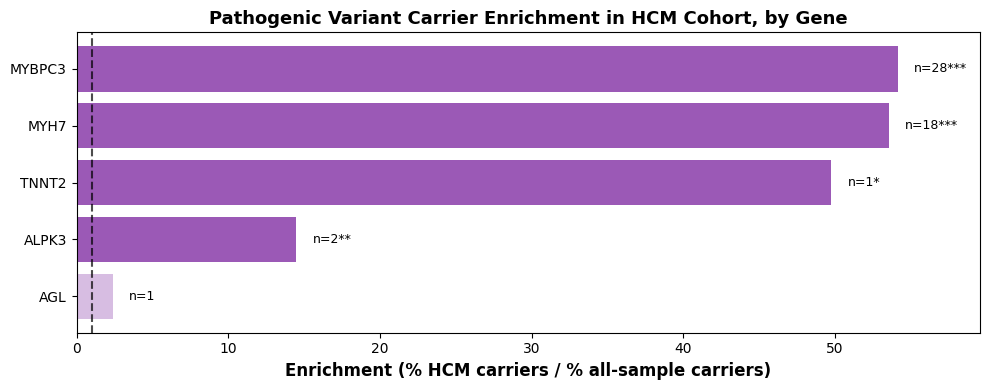

Significant genes (p<0.05): 4/5


In [47]:
# Load gene summary data
summary_df = pd.read_csv("/home/jupyter/prs_hcm_experiment/variant_counts/summary_all_genes.tsv", sep="\t")

# Calculate Fisher's exact test for genes with HCM carriers
enrichment_results = []
for _, row in summary_df[summary_df["HCM_Carriers"] > 0].iterrows():
    hcm_carrier = row["HCM_Carriers"]
    hcm_noncarrier = row["HCM_N"] - row["HCM_Carriers"]
    genpop_carrier = row["All_Carriers"] - row["HCM_Carriers"]
    genpop_noncarrier = (len(cohort) - row["HCM_N"]) - genpop_carrier
    
    or_, ci_low, ci_high = odds_ratio_ci(hcm_carrier, hcm_noncarrier, 
                                          genpop_carrier, genpop_noncarrier)
    _, p_value = fisher_exact([[hcm_carrier, hcm_noncarrier], 
                                [genpop_carrier, genpop_noncarrier]])
    
    enrichment_results.append({
        "Gene": row["Gene"],
        "HCM_Carriers": hcm_carrier,
        "Enrichment": row["Enrichment"],
        "P_value": p_value,
        "Sig": sig_stars(p_value)
    })

enrich_df = pd.DataFrame(enrichment_results).sort_values("Enrichment")

# Plot
fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(enrich_df))))
colors = ["#9b59b6" if p < 0.05 else "#d7bde2" for p in enrich_df["P_value"]]
ax.barh(enrich_df["Gene"], enrich_df["Enrichment"], color=colors)
ax.axvline(1, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Enrichment (% HCM carriers / % all-sample carriers)", fontsize=12, fontweight="bold")
ax.set_title("Pathogenic Variant Carrier Enrichment in HCM Cohort, by Gene", fontsize=13, fontweight="bold")

# Extend x-axis to make room for labels
max_enrich = enrich_df["Enrichment"].max()
ax.set_xlim(0, max_enrich * 1.1)

# Add n= and significance
for i, row in enumerate(enrich_df.itertuples()):
    label = f"n={row.HCM_Carriers}{row.Sig}"
    ax.text(row.Enrichment + max_enrich * 0.02, i, label, va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/carrier_enrichment_by_gene.png", dpi=300, bbox_inches="tight")
plt.show()

# Quick summary
print(f"Significant genes (p<0.05): {(enrich_df['P_value'] < 0.05).sum()}/{len(enrich_df)}")

## 3. PRS Distributions

### 3a. General Population vs. HCM Cohort

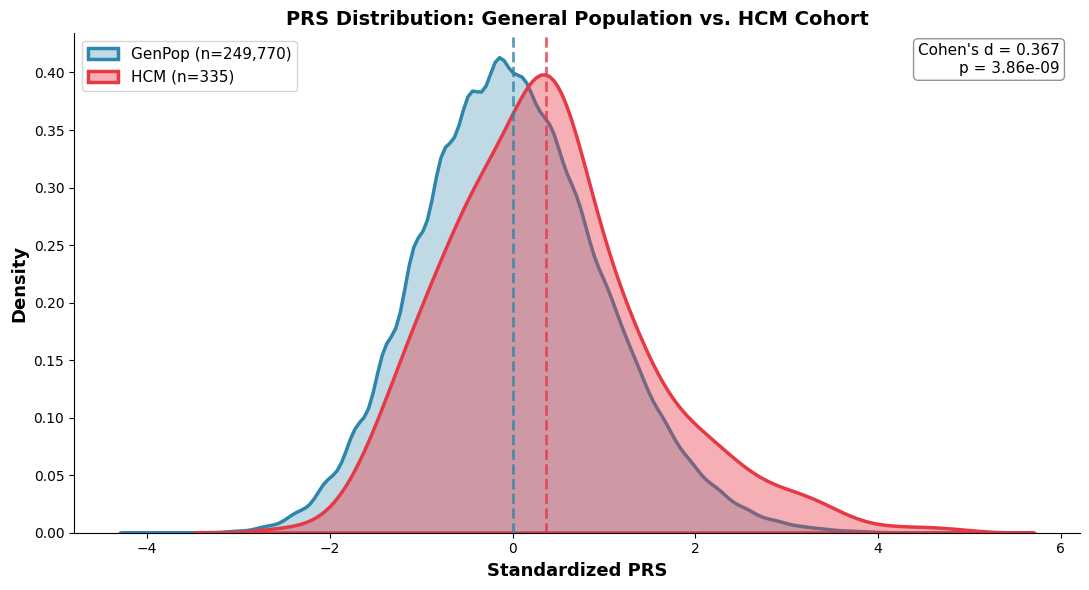

In [48]:
fig, ax = plt.subplots(figsize=(11, 6))
genpop_prs = cohort.loc[~cohort["is_hcm_case"], "prs_standardized"].dropna()
hcm_prs = cohort.loc[cohort["is_hcm_case"], "prs_standardized"].dropna()

sns.kdeplot(genpop_prs, ax=ax, color="#2E86AB", linewidth=2.5, fill=True, alpha=0.3,
            label=f"GenPop (n={len(genpop_prs):,})")
sns.kdeplot(hcm_prs, ax=ax, color="#E63946", linewidth=2.5, fill=True, alpha=0.4,
            label=f"HCM (n={len(hcm_prs):,})")
ax.axvline(genpop_prs.mean(), color="#2E86AB", linestyle="--", linewidth=2, alpha=0.8)
ax.axvline(hcm_prs.mean(), color="#E63946", linestyle="--", linewidth=2, alpha=0.8)

t_stat, p_value = ttest_ind(hcm_prs, genpop_prs, equal_var=False)
cohens_d = (hcm_prs.mean() - genpop_prs.mean()) / genpop_prs.std()

ax.set_xlabel("Standardized PRS", fontsize=13, fontweight="bold")
ax.set_ylabel("Density", fontsize=13, fontweight="bold")
ax.set_title("PRS Distribution: General Population vs. HCM Cohort", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.text(0.98, 0.98, f"Cohen's d = {cohens_d:.3f}\np = {p_value:.2e}", transform=ax.transAxes,
        fontsize=11, verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/prs_distribution_cases_vs_controls.png", dpi=300, bbox_inches="tight")
plt.show()


### 3b. Four-Group PRS Distribution

Stratifies by both disease status and carrier status — tests whether PRS tracks with carrier status within each cohort, and with disease status within each carrier group.

In [49]:
groups_4 = GROUP_ORDER
prs_data_4group = cohort[cohort["cohort_group"].isin(groups_4) & cohort["prs_standardized"].notna()][
    ["cohort_group", "prs_standardized"]
].rename(columns={"cohort_group": "Group", "prs_standardized": "PRS"})

print("Group sizes:")
print(prs_data_4group["Group"].value_counts().reindex(groups_4))

stats_4group = prs_data_4group.groupby("Group")["PRS"].agg([
    ("N", "count"), ("Mean", "mean"), ("Median", "median"), ("Std", "std"),
    ("Q25", lambda x: np.percentile(x, 25)), ("Q75", lambda x: np.percentile(x, 75)),
]).reindex(groups_4).round(4)
print("\nSummary statistics:")
print(stats_4group)

group_arrays_4 = [prs_data_4group[prs_data_4group["Group"] == g]["PRS"].values for g in groups_4]
h_stat_4, p_kruskal_4 = kruskal(*group_arrays_4)
print(f"\nKruskal-Wallis H-test: H={h_stat_4:.4f}, p={p_kruskal_4:.4e}")

pairwise_results = []
for i in range(len(groups_4)):
    for j in range(i + 1, len(groups_4)):
        g1, g2 = groups_4[i], groups_4[j]
        p1 = prs_data_4group[prs_data_4group["Group"] == g1]["PRS"].values
        p2 = prs_data_4group[prs_data_4group["Group"] == g2]["PRS"].values
        stat, pvalue = mannwhitneyu(p1, p2, alternative="two-sided")
        pairwise_results.append({"Group 1": g1, "Group 2": g2, "N1": len(p1), "N2": len(p2),
                                  "Mean1": np.mean(p1), "Mean2": np.mean(p2), "p-value": pvalue,
                                  "Significant": sig_stars(pvalue) or "ns"})
pairwise_4group = pd.DataFrame(pairwise_results)
print("\nPairwise Mann-Whitney U tests:")
print(pairwise_4group.to_string(index=False))


Group sizes:
Group
GenPop Non-Carrier    248260
GenPop Carrier          1510
HCM Non-Carrier          287
HCM Carrier               48
Name: count, dtype: int64

Summary statistics:
                         N    Mean  Median     Std     Q25     Q75
Group                                                             
GenPop Non-Carrier  248260 -0.0001 -0.0449  0.9999 -0.6953  0.6436
GenPop Carrier        1510  0.0089 -0.0291  1.0128 -0.7096  0.6703
HCM Non-Carrier        287  0.3443  0.3311  1.1147 -0.4363  0.8646
HCM Carrier             48  0.5042  0.2478  1.0835 -0.2151  1.2077

Kruskal-Wallis H-test: H=33.3613, p=2.7022e-07

Pairwise Mann-Whitney U tests:
           Group 1         Group 2     N1   N2     Mean1    Mean2      p-value Significant
GenPop Non-Carrier  GenPop Carrier 248260 1510 -0.000064 0.008876 8.324363e-01          ns
GenPop Non-Carrier HCM Non-Carrier 248260  287 -0.000064 0.344265 8.399492e-07         ***
GenPop Non-Carrier     HCM Carrier 248260   48 -0.000064 0.5041

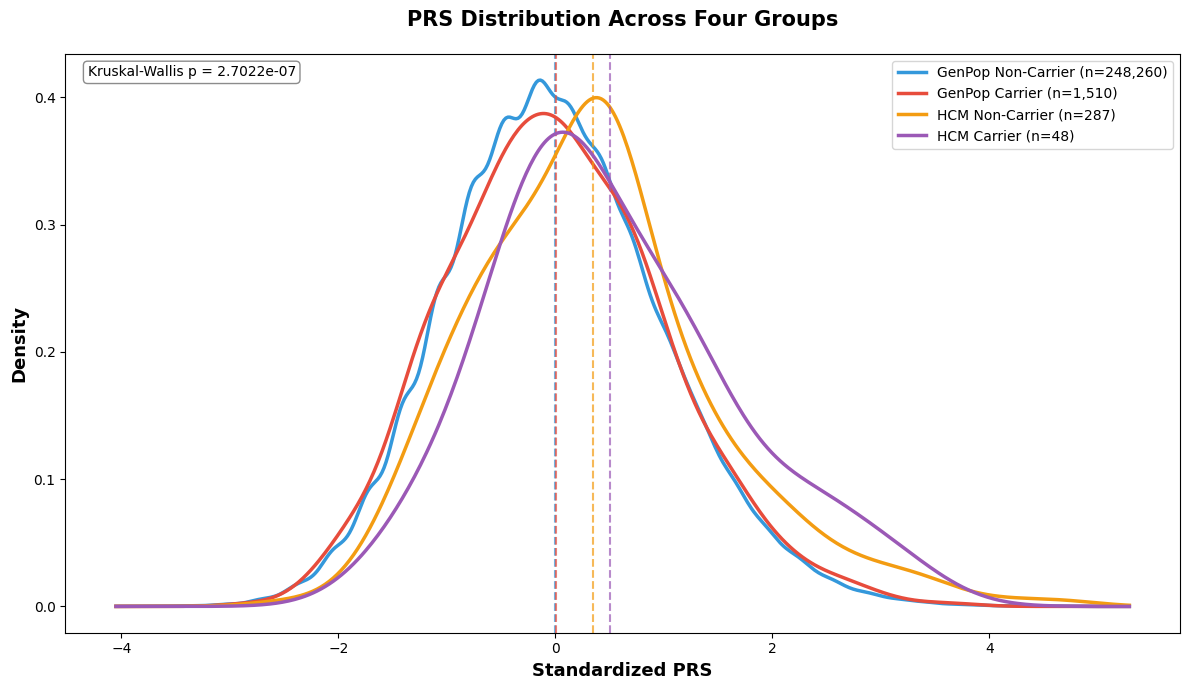

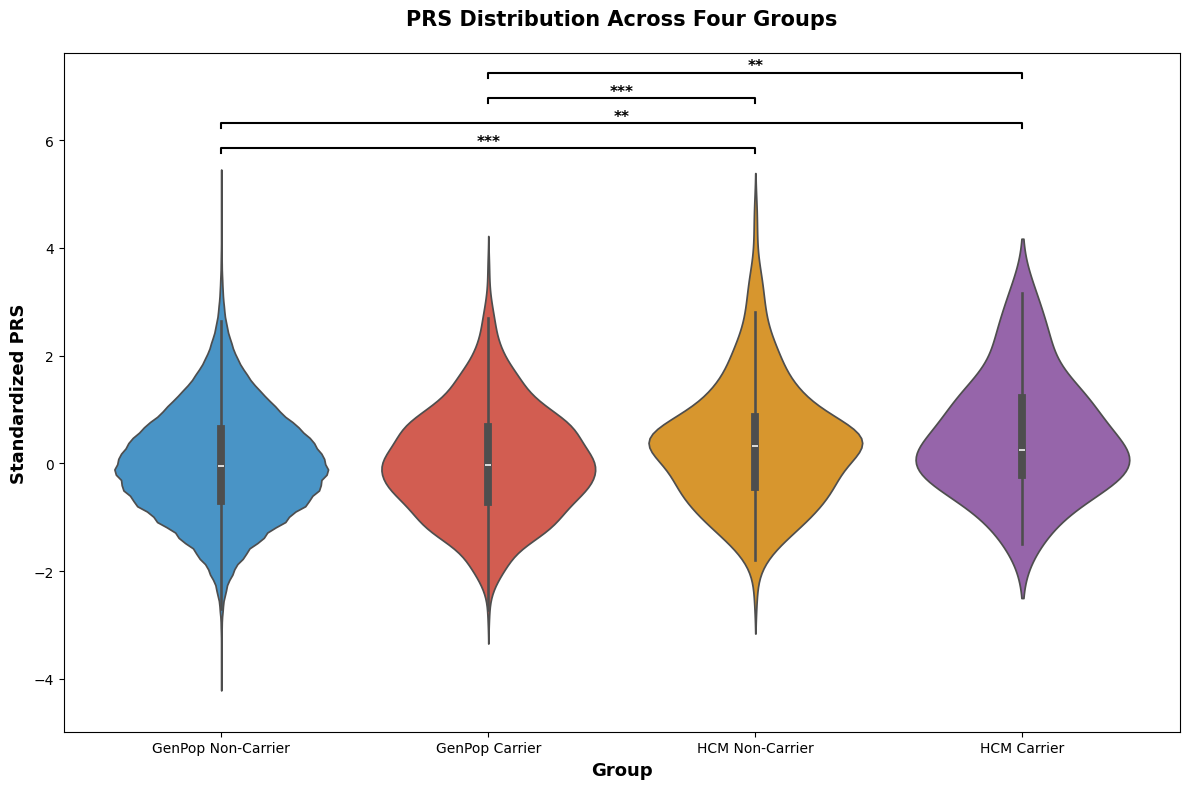

In [50]:
fig, ax = plt.subplots(figsize=(12, 7))
colors_4 = [GROUP_COLORS[g] for g in groups_4]
for group, color in zip(groups_4, colors_4):
    data = prs_data_4group[prs_data_4group["Group"] == group]["PRS"]
    kde = gaussian_kde(data)
    x_range = np.linspace(prs_data_4group["PRS"].min(), prs_data_4group["PRS"].max(), 500)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=f"{group} (n={len(data):,})")
    ax.axvline(data.mean(), color=color, linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Standardized PRS", fontsize=13, fontweight="bold")
ax.set_ylabel("Density", fontsize=13, fontweight="bold")
ax.set_title("PRS Distribution Across Four Groups", fontsize=15, fontweight="bold", pad=20)
ax.legend(loc="upper right", fontsize=10)
ax.text(0.02, 0.98, f"Kruskal-Wallis p = {p_kruskal_4:.4e}", transform=ax.transAxes,
        fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"))
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/prs_4group_density.png", dpi=300, bbox_inches="tight")
plt.show()

# Violin plot with significance
fig, ax = plt.subplots(figsize=(12, 8))
sns.violinplot(data=prs_data_4group, x="Group", y="PRS", order=groups_4, hue="Group", 
               palette=colors_4, inner="box", ax=ax, legend=False)
ax.set_xlabel("Group", fontsize=13, fontweight="bold")
ax.set_ylabel("Standardized PRS", fontsize=13, fontweight="bold")
ax.set_title("PRS Distribution Across Four Groups", fontsize=15, fontweight="bold", pad=20)

# Add pairwise significance - only for p < 0.05
from itertools import combinations
y_max = prs_data_4group["PRS"].max()
y_range = prs_data_4group["PRS"].max() - prs_data_4group["PRS"].min()
h = y_range * 0.05

sig_pairs = []
for g1, g2 in combinations(groups_4, 2):
    d1 = prs_data_4group[prs_data_4group["Group"] == g1]["PRS"]
    d2 = prs_data_4group[prs_data_4group["Group"] == g2]["PRS"]
    stat, p = mannwhitneyu(d1, d2, alternative="two-sided")
    if p < 0.05:
        sig_pairs.append((g1, g2, p))

for i, (g1, g2, p) in enumerate(sig_pairs):
    x1 = groups_4.index(g1)
    x2 = groups_4.index(g2)
    y = y_max + (i + 1) * h
    
    ax.plot([x1, x1, x2, x2], [y, y + h*0.2, y + h*0.2, y], color="black", linewidth=1.5)
    ax.text((x1 + x2) / 2, y + h*0.3, sig_stars(p), ha="center", fontsize=11, fontweight="bold")

ax.set_ylim(prs_data_4group["PRS"].min() - 0.1 * y_range, y_max + (len(sig_pairs) + 1) * h)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/prs_4group_violin.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Age of Onset: HCM Carriers vs Non-Carriers

Among HCM patients, do carriers of a pathogenic variant get diagnosed
earlier than non-carriers? Uses `age_at_hcm_diagnosis`, computed in the
setup notebook.

HCM Carriers (n=48): mean=44.0, median=45.7, SD=17.6
HCM Non-Carriers (n=287): mean=54.9, median=56.9, SD=17.2

Mann-Whitney U: p=0.0001 | Welch's t-test: p=0.0002


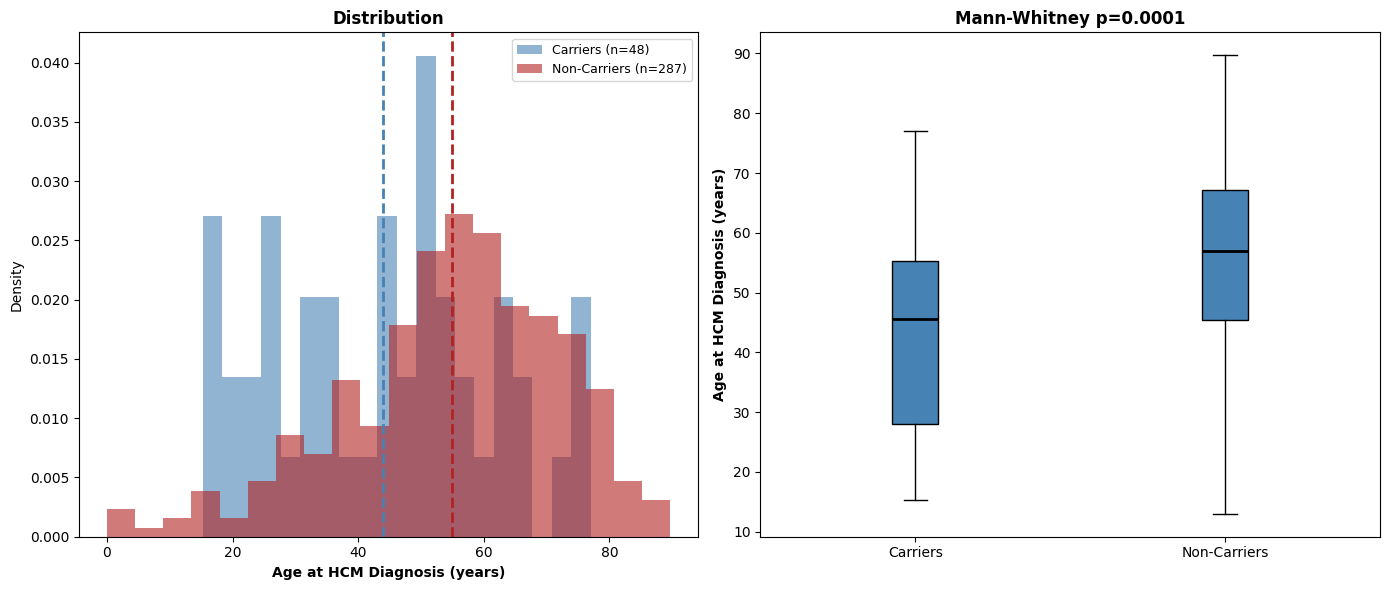

In [51]:
hcm_cohort_df = cohort[cohort["is_hcm_case"]]
carriers_age = hcm_cohort_df.loc[hcm_cohort_df["is_carrier"], "age_at_hcm_diagnosis"].dropna()
noncarriers_age = hcm_cohort_df.loc[~hcm_cohort_df["is_carrier"], "age_at_hcm_diagnosis"].dropna()

u_stat, p_mw = mannwhitneyu(carriers_age, noncarriers_age, alternative="two-sided")
t_stat, p_tt = ttest_ind(carriers_age, noncarriers_age, equal_var=False)

print(f"HCM Carriers (n={len(carriers_age)}): mean={carriers_age.mean():.1f}, median={carriers_age.median():.1f}, SD={carriers_age.std():.1f}")
print(f"HCM Non-Carriers (n={len(noncarriers_age)}): mean={noncarriers_age.mean():.1f}, median={noncarriers_age.median():.1f}, SD={noncarriers_age.std():.1f}")
print(f"\nMann-Whitney U: p={p_mw:.4f} | Welch's t-test: p={p_tt:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(carriers_age, bins=20, alpha=0.6, label=f"Carriers (n={len(carriers_age)})", color="steelblue", density=True)
axes[0].hist(noncarriers_age, bins=20, alpha=0.6, label=f"Non-Carriers (n={len(noncarriers_age)})", color="firebrick", density=True)
axes[0].axvline(carriers_age.mean(), color="steelblue", linestyle="--", linewidth=2)
axes[0].axvline(noncarriers_age.mean(), color="firebrick", linestyle="--", linewidth=2)
axes[0].set_xlabel("Age at HCM Diagnosis (years)", fontweight="bold")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution", fontweight="bold")
axes[0].legend(fontsize=9)

axes[1].boxplot([carriers_age, noncarriers_age], tick_labels=["Carriers", "Non-Carriers"], patch_artist=True,
                boxprops=dict(facecolor="steelblue"), medianprops=dict(color="black", linewidth=2),
                showfliers=False)
axes[1].set_ylabel("Age at HCM Diagnosis (years)", fontweight="bold")
axes[1].set_title(f"Mann-Whitney p={p_mw:.4f}", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/age_of_onset_carriers_vs_noncarriers.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. PRS-Quartile Penetrance & Event Rates

The primary hypothesis test. We run this analysis twice:

**GenPop Carriers** (P+ without HCM diagnosis at enrollment):
   - Does PRS predict clinical events among those who don't develop HCM?
   - The "has_hcm" endpoint represents incident HCM diagnosis
   - Q4-vs-Q1 odds ratio for HCM = relative risk of disease penetrance by PRS quartile

**HCM Carriers** (P+ with existing HCM diagnosis):
   - Among people already diagnosed with HCM, does PRS predict worse outcomes?
   - This is a disease severity/progression question, not penetrance
   - Events include heart failure, arrhythmias, and other major adverse cardiac events

## 7a. Penetrance by PRS Quartile — All Pathogenic Variant Carriers

**Research question:** Among people carrying a pathogenic HCM variant, does polygenic background (PRS) modify the likelihood of actually developing HCM?

**Population:** All pathogenic variant carriers with a PRS quartile assigned — combining `HCM Carrier` and `GenPop Carrier` cohort groups. Both are included deliberately: restricting to `GenPop Carrier` alone would exclude the confirmed HCM Carriers, who are by definition carriers who *do* have the outcome — removing them would artificially deflate penetrance rather than measure it correctly. Penetrance is defined over the full carrier population, regardless of which `cohort_group` bucket they happen to fall into.

**Outcome (`hcm_any`):** the union of both diagnosis definitions — `is_hcm_case` (strict cohort criteria) OR `has_hcm` (minimal ≥2-codes/≥2-dates criteria) — to avoid undercounting penetrance among carriers who show real diagnostic evidence of HCM but don't meet the full strict cohort-eligibility bar.

**Ascertainment note:** carrier status here was determined via population-wide genotyping, not via clinically-triggered genetic testing — i.e., carriers were not identified *because* a clinician suspected HCM. This distinguishes this penetrance estimate from typical clinic-ascertained estimates, which tend to be inflated by testing only symptomatic individuals.

**What this cell does:**
1. Builds `hcm_any` as the union outcome described above
2. Filters to all carriers (HCM Carrier + GenPop Carrier) with a PRS quartile assigned
3. Prints overall carrier counts (total, by cohort group) and overall penetrance rate
4. Calls `render_penetrance_barplot()` to produce a 2-panel figure:
   - **Top panel:** penetrance (%) per PRS quartile, with Wilson-score 95% confidence intervals (chosen over normal-approximation CIs since event counts per quartile can be small) and the overall penetrance rate shown as a reference line
   - **Bottom panel:** relative risk of each quartile vs. Q1 (lowest PRS), as a horizontal bar chart

**Output:** `pen_df` (per-quartile penetrance rate, n, CI) and `rr_df` (relative risk vs. Q1), plus the saved figure `penetrance_by_prs_quartile.png`.

Total carriers with PRS quartile assigned: 1,558
cohort_group
GenPop Carrier    1510
HCM Carrier         48
Name: count, dtype: int64

Overall penetrance (hcm_any) among all carriers:
  142 / 1,558 (9.1%)


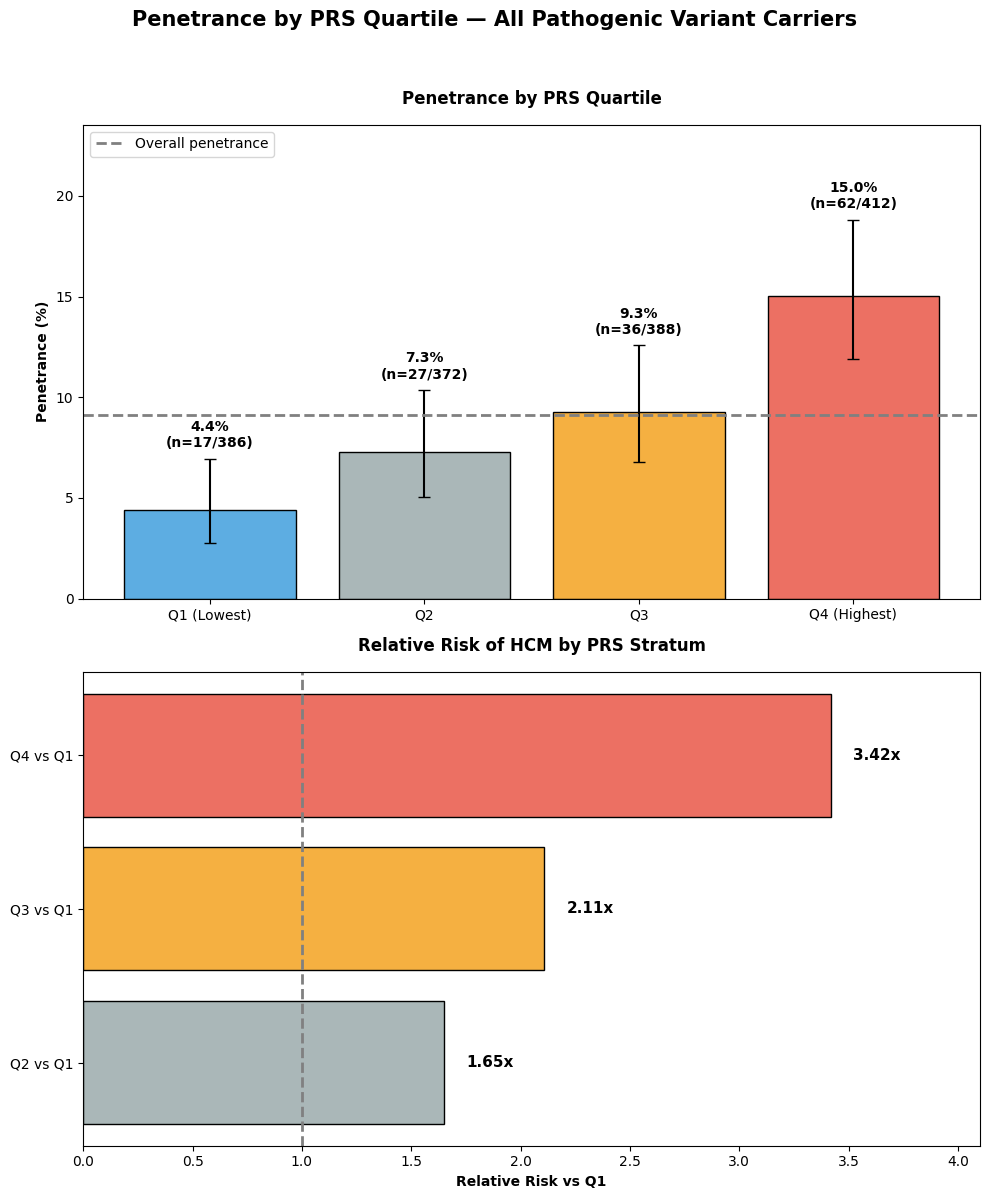

In [52]:
cohort["hcm_any"] = cohort["is_hcm_case"] | cohort["has_hcm"]

all_carrier_quartiles = cohort[
    (cohort["cohort_group"].isin(["HCM Carrier", "GenPop Carrier"])) & cohort["prs_quartile"].notna()
]

print(f"Total carriers with PRS quartile assigned: {len(all_carrier_quartiles):,}")
print(all_carrier_quartiles["cohort_group"].value_counts())
print("\nOverall penetrance (hcm_any) among all carriers:")
print(f"  {all_carrier_quartiles['hcm_any'].sum():,} / {len(all_carrier_quartiles):,} "
      f"({100*all_carrier_quartiles['hcm_any'].mean():.1f}%)")

pen_df, rr_df = render_penetrance_barplot(
    all_carrier_quartiles, "hcm_any",
    title="Penetrance by PRS Quartile — All Pathogenic Variant Carriers",
    savepath=f"{PLOT_DIR}/penetrance_by_prs_quartile.png"
)

## 7b. Kaplan-Meier: Age at HCM Onset by PRS Quartile

**Research question:** Does PRS predict *when*, not just *whether*, a pathogenic variant carrier develops HCM?

**Event definition (`hcm_any`):** union of `is_hcm_case` and `has_hcm`, same rationale as the penetrance analysis — avoids undercounting real diagnoses among carriers who don't meet strict cohort criteria.

**Event/censoring time:**
- **Cases:** age at the earliest available diagnosis-evidence date -> the minimum of `first_hcm_date` (strict cohort diagnosis) and `first_hcm_flag_date` (minimal-criteria `has_hcm` diagnosis date), whichever is earlier.
- **Non-cases (censored):** age at `last_visit_date` -> the most recent recorded clinical activity across all OMOP event tables, representing the latest point at which the person is known to have remained disease-free.

**What this cell does:**
1. Builds `hcm_any`, `event_date`, and `age_at_event_or_censor` for all carriers
2. Runs sanity checks: counts of events vs. censored, missing dates, negative ages (data-quality red flags)
3. Fits and plots Kaplan-Meier survival curves separately for each PRS quartile (HCM-free survival probability vs. age), with 95% confidence bands
4. Runs a multivariate log-rank test (overall difference across all 4 quartiles) and pairwise log-rank tests (each quartile vs. every other)

**Interpretation note:** the right-hand tail of each curve (oldest ages) is estimated from a shrinking number of people still at risk (neither diagnosed nor lost to follow-up), so it is progressively less reliable. This is visible in the widening confidence bands. Treat curve separation at very old ages as suggestive rather than precise.

In [15]:
cohort = client.query(f"""
SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort`
""").to_dataframe()
print(f"Reloaded {len(cohort):,} persons")

Reloaded 250,105 persons


Total carriers in KM analysis: 1,558
Events (HCM diagnosed, is_hcm_case or has_hcm): 142
Censored (not yet diagnosed): 1,416

Missing event_date (no diagnosis date AND no last_visit_date): 2

Age at event/censor summary:
count    1556.000000
mean       50.143727
std        21.487870
min         0.016427
25%        33.431211
50%        52.353183
75%        67.600958
max        89.998631
Name: age_at_event_or_censor, dtype: float64

Negative ages (data issue, e.g. event before birth_date): 0

Usable for KM: 1,556 / 1,558
                count  sum
cohort_group              
GenPop Carrier   1508   94
HCM Carrier        48   48


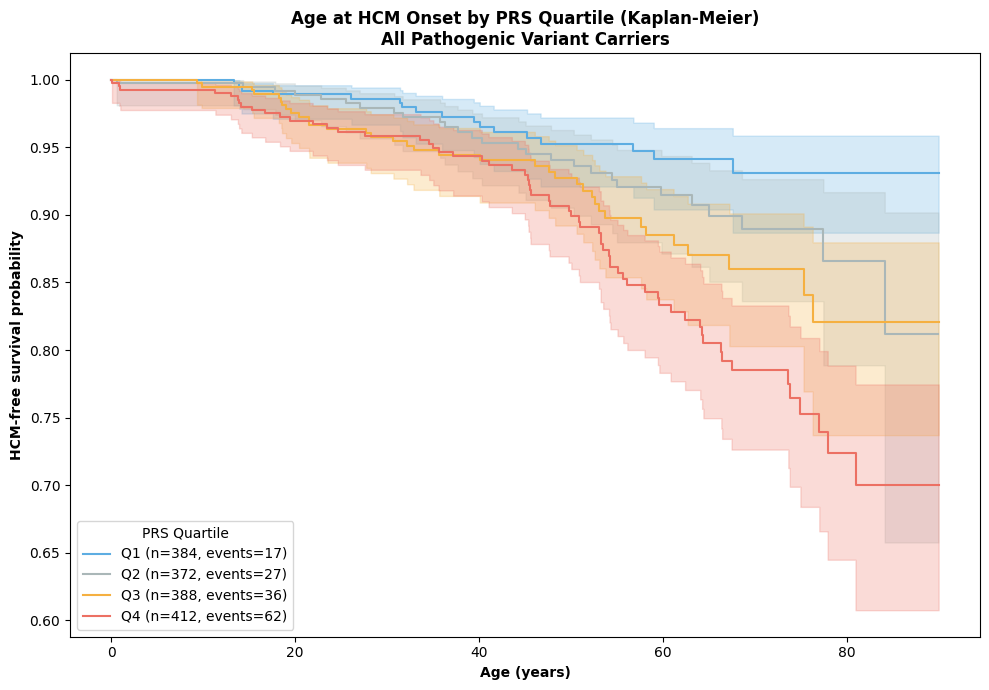


Log-rank test (all 4 quartiles): p = 0.0000

Pairwise log-rank tests:
       test_statistic         p
Q1 Q2        2.303862  0.129053
   Q3        7.357194  0.006679
   Q4       20.339095  0.000006
Q2 Q3        1.456950  0.227416
   Q4        9.803381  0.001742
Q3 Q4        3.485341  0.061915


In [53]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
from lifelines import CoxPHFitter

# --- Build time-to-event data for all pathogenic variant carriers ---
carriers = cohort[
    (cohort["cohort_group"].isin(["HCM Carrier", "GenPop Carrier"])) & cohort["prs_quartile"].notna()
].copy()

carriers["birth_date"] = pd.to_datetime(carriers["birth_date"])
carriers["first_hcm_date"] = pd.to_datetime(carriers["first_hcm_date"])
carriers["first_hcm_flag_date"] = pd.to_datetime(carriers["first_hcm_flag_date"])
carriers["last_visit_date"] = pd.to_datetime(carriers["last_visit_date"])

# hcm_any: union of both case definitions
carriers["hcm_any"] = carriers["is_hcm_case"] | carriers["has_hcm"]

# Event date: earliest of the two possible diagnosis-evidence dates, when present
carriers["earliest_hcm_evidence_date"] = carriers[["first_hcm_date", "first_hcm_flag_date"]].min(axis=1)

# event_date: earliest HCM evidence date for cases; last_visit_date (censoring) for non-cases
carriers["event_date"] = np.where(
    carriers["hcm_any"],
    carriers["earliest_hcm_evidence_date"],
    carriers["last_visit_date"]
)
carriers["event_date"] = pd.to_datetime(carriers["event_date"])

carriers["age_at_event_or_censor"] = (carriers["event_date"] - carriers["birth_date"]).dt.days / 365.25
carriers["event_observed"] = carriers["hcm_any"].astype(int)

# --- Sanity checks before fitting ---
print(f"Total carriers in KM analysis: {len(carriers):,}")
print(f"Events (HCM diagnosed, is_hcm_case or has_hcm): {carriers['event_observed'].sum():,}")
print(f"Censored (not yet diagnosed): {(carriers['event_observed'] == 0).sum():,}")

n_missing_date = carriers["event_date"].isna().sum()
print(f"\nMissing event_date (no diagnosis date AND no last_visit_date): {n_missing_date:,}")

print(f"\nAge at event/censor summary:")
print(carriers["age_at_event_or_censor"].describe())

n_negative = (carriers["age_at_event_or_censor"] < 0).sum()
print(f"\nNegative ages (data issue, e.g. event before birth_date): {n_negative:,}")

# Drop anyone with missing/invalid age
carriers_km = carriers.dropna(subset=["age_at_event_or_censor"])
carriers_km = carriers_km[carriers_km["age_at_event_or_censor"] >= 0]
print(f"\nUsable for KM: {len(carriers_km):,} / {len(carriers):,}")
print(carriers_km.groupby("cohort_group")["event_observed"].agg(["count", "sum"]))

# --- KM curves by PRS quartile ---
fig, ax = plt.subplots(figsize=(10, 7))
quartile_colors = {"Q1": "#5DADE2", "Q2": "#AAB7B8", "Q3": "#F5B041", "Q4": "#EC7063"}
kmfs = {}

for q in ["Q1", "Q2", "Q3", "Q4"]:
    sub = carriers_km[carriers_km["prs_quartile"] == q]
    kmf = KaplanMeierFitter()
    kmf.fit(sub["age_at_event_or_censor"], event_observed=sub["event_observed"],
            label=f"{q} (n={len(sub)}, events={sub['event_observed'].sum()})")
    kmf.plot_survival_function(ax=ax, color=quartile_colors[q], ci_show=True)
    kmfs[q] = kmf

ax.set_xlabel("Age (years)", fontweight="bold")
ax.set_ylabel("HCM-free survival probability", fontweight="bold")
ax.set_title("Age at HCM Onset by PRS Quartile (Kaplan-Meier)\nAll Pathogenic Variant Carriers", fontweight="bold")
ax.legend(title="PRS Quartile", loc="lower left")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/km_age_at_onset_by_prs_quartile.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Log-rank test across all 4 quartiles ---
result = multivariate_logrank_test(
    carriers_km["age_at_event_or_censor"], carriers_km["prs_quartile"], carriers_km["event_observed"]
)
print(f"\nLog-rank test (all 4 quartiles): p = {result.p_value:.4f}")

# --- Pairwise log-rank tests ---
pairwise = pairwise_logrank_test(
    carriers_km["age_at_event_or_censor"], carriers_km["prs_quartile"], carriers_km["event_observed"]
)
print("\nPairwise log-rank tests:")
print(pairwise.summary[["test_statistic", "p"]])

## 7c. Cox Proportional Hazards: PRS as a Continuous Predictor

**Purpose:** The quartile-based KM/log-rank analysis above discretizes PRS into 4 bins, which discards information and reduces statistical power. A Cox model uses PRS as a continuous predictor instead, which is expected to have more power to detect a real effect at this sample size — same logic as the continuous PRS regression used for the severity/penetrance analyses elsewhere in this notebook.
**Model:** hazard of HCM onset ~ `prs_standardized`, fit on the same `age_at_event_or_censor` / `event_observed` data built above.

**Output:** the model coefficient is converted to a hazard ratio (HR) per 1-SD increase in PRS, with a 95% confidence interval. This is the headline effect-size number for the penetrance/age-of-onset analysis.

In [54]:
# --- Cox proportional hazards: PRS as continuous predictor ---
cox_df = carriers_km[["age_at_event_or_censor", "event_observed", "prs_standardized"]].dropna()
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="age_at_event_or_censor", event_col="event_observed")
print("\nCox PH model, continuous PRS:")
cph.print_summary()

hr = np.exp(cph.params_["prs_standardized"])
ci_low, ci_high = np.exp(cph.confidence_intervals_.loc["prs_standardized"])
print(f"\nHazard ratio per 1-SD PRS increase: {hr:.3f} (95% CI {ci_low:.3f}-{ci_high:.3f})")


Cox PH model, continuous PRS:


<lifelines.CoxPHFitter: fitted with 1556 total observations, 1414 right-censored observations>
             duration col = 'age_at_event_or_censor'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 1556
number of events observed = 142
   partial log-likelihood = -944.04
         time fit was run = 2026-09-14 15:10:12 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
prs_standardized  0.39      1.48      0.08            0.24            0.55                1.28                1.73

                  cmp to    z      p  -log2(p)
covariate                                     
prs_standardized    0.00 5.11 <0.005     21.55
---
Concordance = 0.61
Partial AIC = 1890.08
log-likelihood ratio test = 25.30 on 1 df
-log2(p) of ll-ratio test = 20.96


Hazard ratio per 1-SD PRS increase: 1.484 (95% CI 1.276-1.727)


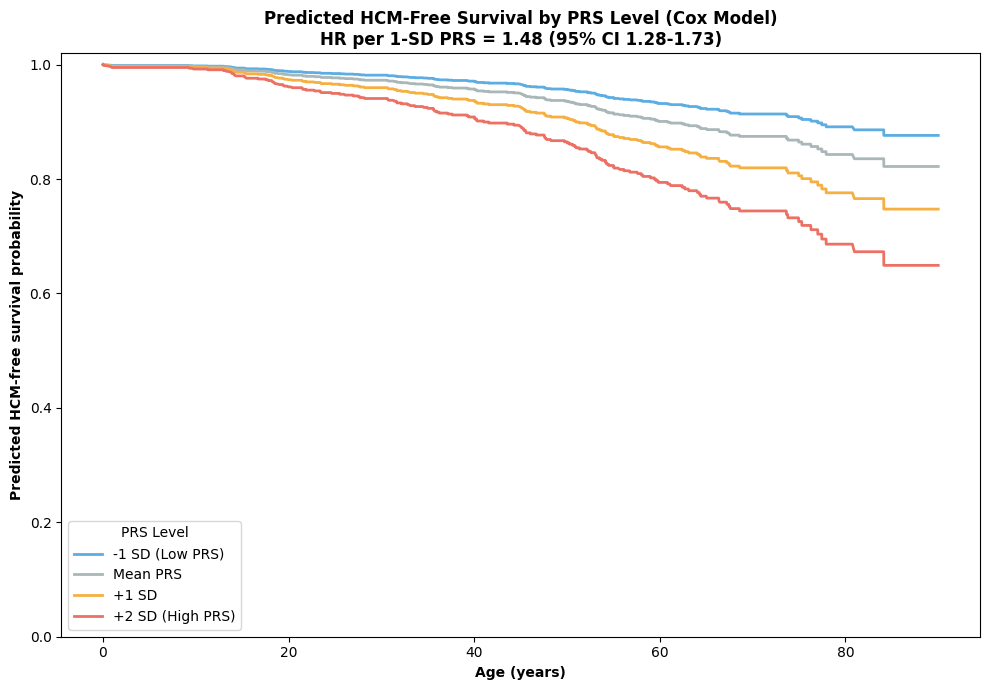

In [69]:
# Predicted survival curves from the Cox model at representative PRS levels
prs_levels = {
    "-1 SD (Low PRS)": -1,
    "Mean PRS": 0,
    "+1 SD": 1,
    "+2 SD (High PRS)": 2,
}

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#5DADE2", "#AAB7B8", "#F5B041", "#EC7063"]

for (label, prs_val), color in zip(prs_levels.items(), colors):
    covariate_df = pd.DataFrame({"prs_standardized": [prs_val]})
    sf = cph.predict_survival_function(covariate_df)
    ax.plot(sf.index, sf.iloc[:, 0], label=label, color=color, linewidth=2)

ax.set_xlabel("Age (years)", fontweight="bold")
ax.set_ylabel("Predicted HCM-free survival probability", fontweight="bold")
ax.set_title(f"Predicted HCM-Free Survival by PRS Level (Cox Model)\n"
             f"HR per 1-SD PRS = {hr:.2f} (95% CI {ci_low:.2f}-{ci_high:.2f})", fontweight="bold")
ax.legend(title="PRS Level")
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/cox_predicted_survival_by_prs_level.png", dpi=300, bbox_inches="tight")
plt.show()


GenPop carriers with PRS quartile assigned: 1,510

Distribution across quartiles:
prs_quartile
Q1    382
Q2    361
Q3    374
Q4    393
Name: count, dtype: int64


/var/tmp/ipykernel_5227/1387223487.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


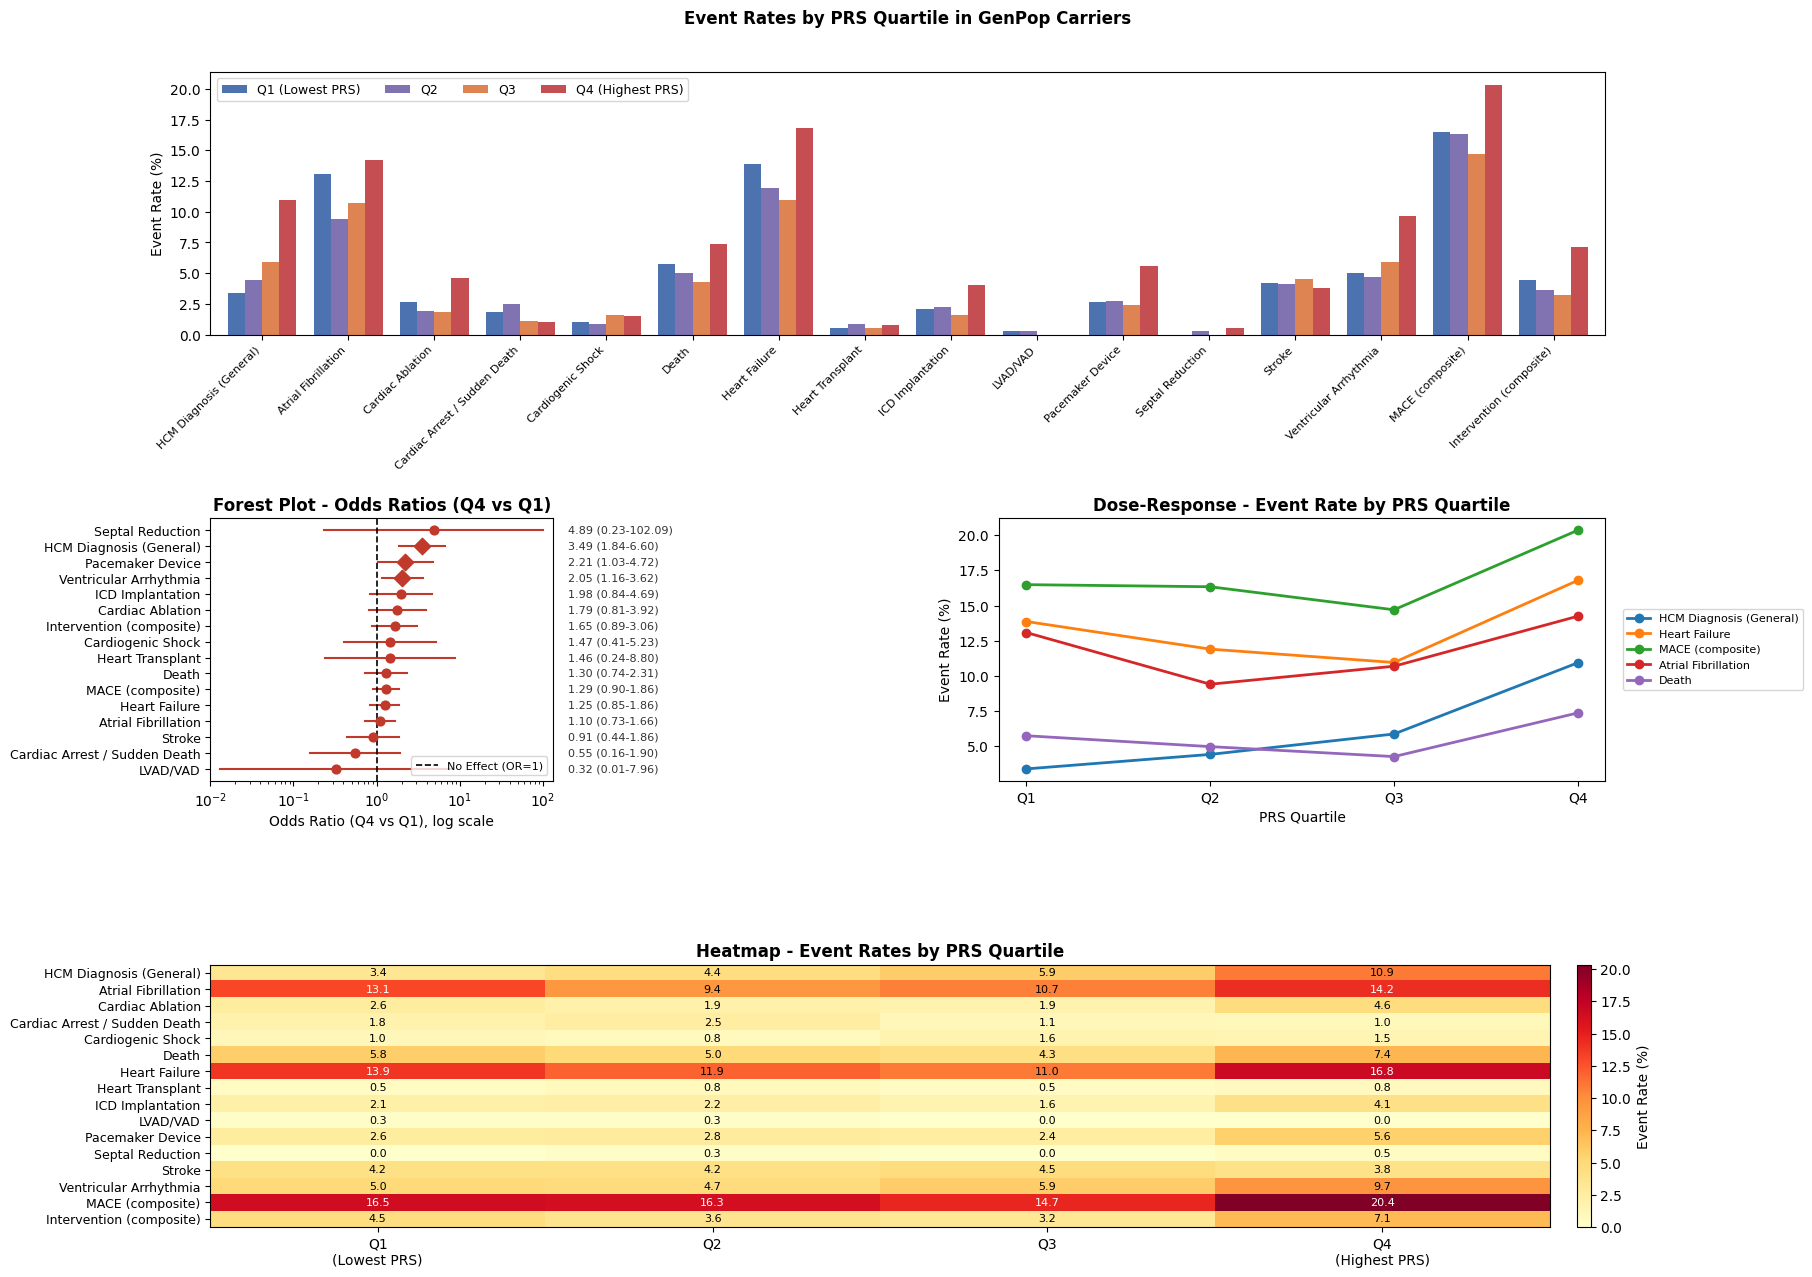

GenPop Carriers: Q4 vs Q1 Odds Ratios (n=16 tests)
                        event    or  ci_low  ci_high  pvalue sig_raw  p_bonferroni sig_bonferroni  p_fdr sig_fdr
                     LVAD/VAD 0.323   0.013    7.958   0.493                 1.000                 0.666        
Cardiac Arrest / Sudden Death 0.551   0.160    1.897   0.378                 1.000                 0.620        
                       Stroke 0.908   0.442    1.863   0.856                 1.000                 0.913        
          Atrial Fibrillation 1.103   0.732    1.663   0.676                 1.000                 0.832        
                Heart Failure 1.253   0.846    1.855   0.274                 1.000                 0.548        
             MACE (composite) 1.294   0.898    1.865   0.195                 1.000                 0.445        
                        Death 1.304   0.735    2.312   0.388                 1.000                 0.620        
             Heart Transplant 1.462   0.243  

/var/tmp/ipykernel_5227/1387223487.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


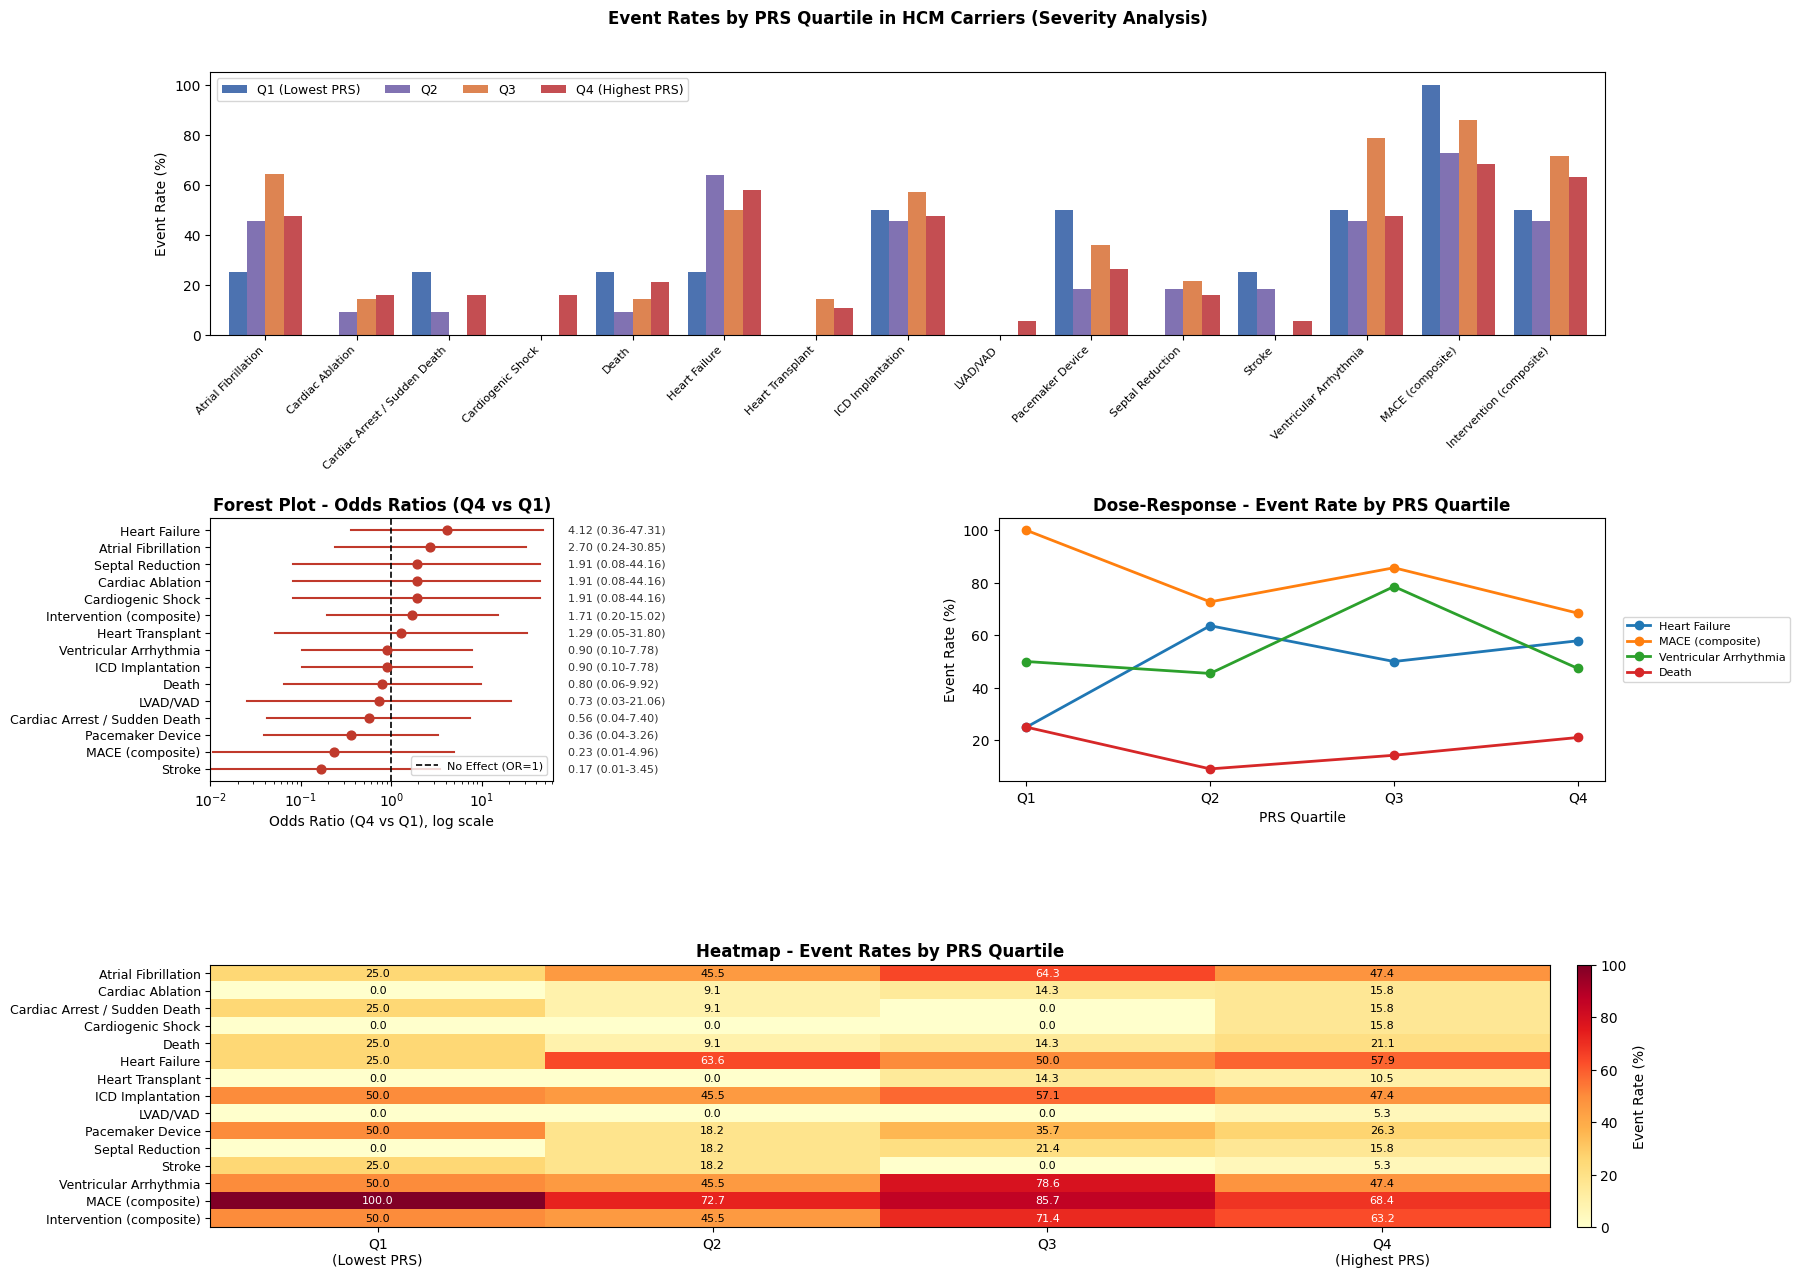

HCM Carriers: Q4 vs Q1 Odds Ratios (n=15 tests)
                        event    or  ci_low  ci_high  pvalue sig_raw  p_bonferroni sig_bonferroni  p_fdr sig_fdr
                       Stroke 0.167   0.008    3.447   0.324                   1.0                   1.0        
             MACE (composite) 0.231   0.011    4.961   0.539                   1.0                   1.0        
             Pacemaker Device 0.357   0.039    3.256   0.557                   1.0                   1.0        
Cardiac Arrest / Sudden Death 0.562   0.043    7.404   1.000                   1.0                   1.0        
                     LVAD/VAD 0.730   0.025   21.058   1.000                   1.0                   1.0        
                        Death 0.800   0.065    9.920   1.000                   1.0                   1.0        
             ICD Implantation 0.900   0.104    7.781   1.000                   1.0                   1.0        
       Ventricular Arrhythmia 0.900   0.104    7

In [63]:
from statsmodels.stats.multitest import multipletests

genpop_carrier_quartiles = cohort[(cohort["cohort_group"] == "GenPop Carrier") & cohort["prs_quartile"].notna()]
print(f"\nGenPop carriers with PRS quartile assigned: {len(genpop_carrier_quartiles):,}")
print("\nDistribution across quartiles:")
print(genpop_carrier_quartiles["prs_quartile"].value_counts().reindex(["Q1", "Q2", "Q3", "Q4"]))

genpop_quartile_df, genpop_forest_df = render_prs_quartile_dashboard(
    genpop_carrier_quartiles,
    event_cols=["has_hcm"] + EVENT_COLS + COMPOSITE_COLS,
    headline_events=["HCM Diagnosis (General)", "Heart Failure", "MACE (composite)", "Atrial Fibrillation", "Death"],
    title="Event Rates by PRS Quartile in GenPop Carriers",
    savepath=f"{PLOT_DIR}/genpop_carriers_prs_quartile_events.png",
)

# --- Significance annotations (raw, Bonferroni, FDR) ---
n_tests = len(genpop_forest_df)
genpop_forest_df["sig_raw"] = np.where(genpop_forest_df["pvalue"] < 0.05, "*", "")
genpop_forest_df["p_bonferroni"] = (genpop_forest_df["pvalue"] * n_tests).clip(upper=1.0)
genpop_forest_df["sig_bonferroni"] = np.where(genpop_forest_df["p_bonferroni"] < 0.05, "*", "")
_, p_fdr, _, _ = multipletests(genpop_forest_df["pvalue"], method="fdr_bh")
genpop_forest_df["p_fdr"] = p_fdr
genpop_forest_df["sig_fdr"] = np.where(genpop_forest_df["p_fdr"] < 0.05, "*", "")

print(f"GenPop Carriers: Q4 vs Q1 Odds Ratios (n={n_tests} tests)")
print(genpop_forest_df[["event", "or", "ci_low", "ci_high", "pvalue", "sig_raw",
                         "p_bonferroni", "sig_bonferroni", "p_fdr", "sig_fdr"]]
      .round(3).to_string(index=False))


hcm_carrier_quartiles = cohort[(cohort["cohort_group"] == "HCM Carrier") & cohort["prs_quartile"].notna()]
print(f"\nHCM carriers with PRS quartile assigned: {len(hcm_carrier_quartiles):,}")
print("\nDistribution across quartiles:")
print(hcm_carrier_quartiles["prs_quartile"].value_counts().reindex(["Q1", "Q2", "Q3", "Q4"]))

hcm_quartile_df, hcm_forest_df = render_prs_quartile_dashboard(
    hcm_carrier_quartiles,
    event_cols=EVENT_COLS + COMPOSITE_COLS,
    headline_events=["Heart Failure", "MACE (composite)", "Ventricular Arrhythmia", "Death"],
    title="Event Rates by PRS Quartile in HCM Carriers (Severity Analysis)",
    savepath=f"{PLOT_DIR}/hcm_carriers_prs_quartile_events.png",
)

# --- Significance annotations (raw, Bonferroni, FDR) ---
n_tests = len(hcm_forest_df)
hcm_forest_df["sig_raw"] = np.where(hcm_forest_df["pvalue"] < 0.05, "*", "")
hcm_forest_df["p_bonferroni"] = (hcm_forest_df["pvalue"] * n_tests).clip(upper=1.0)
hcm_forest_df["sig_bonferroni"] = np.where(hcm_forest_df["p_bonferroni"] < 0.05, "*", "")
_, p_fdr, _, _ = multipletests(hcm_forest_df["pvalue"], method="fdr_bh")
hcm_forest_df["p_fdr"] = p_fdr
hcm_forest_df["sig_fdr"] = np.where(hcm_forest_df["p_fdr"] < 0.05, "*", "")

print(f"HCM Carriers: Q4 vs Q1 Odds Ratios (n={n_tests} tests)")
print(hcm_forest_df[["event", "or", "ci_low", "ci_high", "pvalue", "sig_raw",
                      "p_bonferroni", "sig_bonferroni", "p_fdr", "sig_fdr"]]
      .round(3).to_string(index=False))

## 5. Per-Gene Event Enrichment

Same question as §4, split by which gene the pathogenic variant is in.
Uses the two composite outcomes (`has_mace`, `has_intervention`) rather than
all 14 individual categories per gene — full per-category-per-gene detail
multiplies the multiple-testing problem noted above without changing the
headline story; add individual categories the same way if you need them.
`carrier_genes` is a semicolon-joined string (a person can carry variants in
more than one gene), so genes are exploded before grouping. Genes with fewer
than `MIN_CARRIERS` in a cohort are dropped from that cohort's plot — with
this few HCM carriers overall, most individual genes won't have enough
carriers to report a stable estimate.


MACE (composite) - HCM cohort, by gene:
  gene  n_carriers  n_events  event_pct    or  ci_low  ci_high  pvalue  p_fdr  sig_raw  sig_fdr
MYBPC3          28        21     75.000 1.508   0.619    3.671   0.407  0.441    False    False
  MYH7          18        14     77.778 1.759   0.564    5.489   0.441  0.441    False    False

MACE (composite) - GenPop, by gene:
  gene  n_carriers  n_events  event_pct    or  ci_low  ci_high  pvalue  p_fdr  sig_raw  sig_fdr
  TCAP          13         1      7.692 0.595   0.077    4.573   1.000  1.000    False    False
  MYL2          10         1     10.000 0.793   0.100    6.257   1.000  1.000    False    False
ACADVL         233        31     13.305 1.095   0.750    1.598   0.618  0.755    False    False
  MTO1         136        21     15.441 1.303   0.818    2.075   0.294  0.405    False    False
   AGL         311        52     16.720 1.432   1.063    1.930   0.024  0.066     True    False
 ALPK3         101        17     16.832 1.444   0.857    2

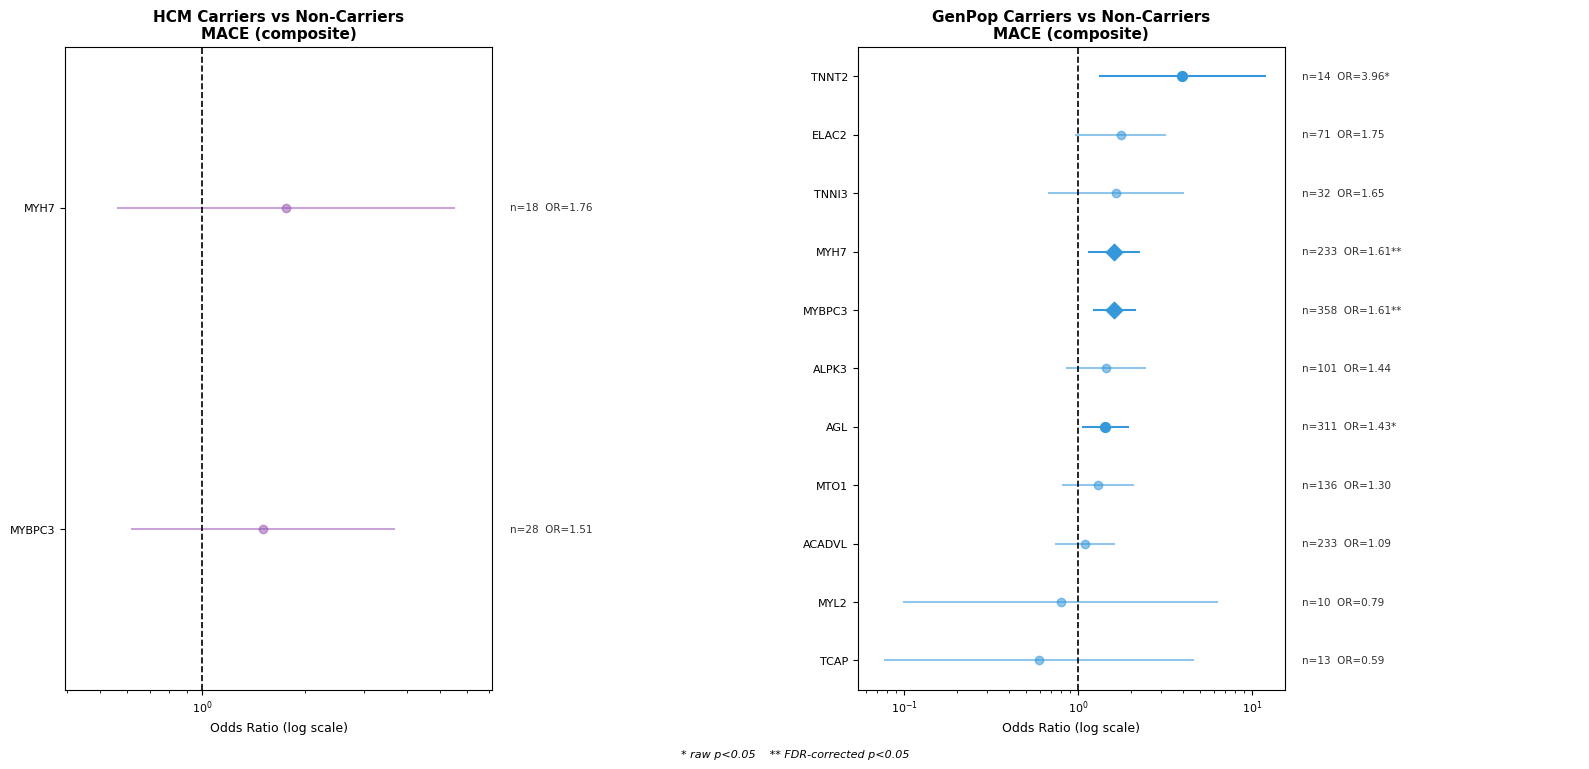


Intervention (composite) - HCM cohort, by gene:
  gene  n_carriers  n_events  event_pct    or  ci_low  ci_high  pvalue  p_fdr  sig_raw  sig_fdr
  MYH7          18        10     55.556 3.021   1.152    7.920   0.032  0.032     True     True
MYBPC3          28        17     60.714 3.735   1.678    8.311   0.001  0.002     True     True

Intervention (composite) - GenPop, by gene:
  gene  n_carriers  n_events  event_pct    or  ci_low  ci_high  pvalue  p_fdr  sig_raw  sig_fdr
 ALPK3         101         0      0.000 0.274   0.017    4.412   0.430  0.683    False    False
   AGL         311         4      1.286 0.725   0.270    1.944   0.668  0.817    False    False
ACADVL         233         4      1.717 0.972   0.361    2.612   1.000  1.000    False    False
  MTO1         136         3      2.206 1.255   0.399    3.942   0.520  0.715    False    False
 TNNI3          32         1      3.125 1.794   0.245   13.148   0.435  0.683    False    False
  MYL2          10         0      0.000 2.

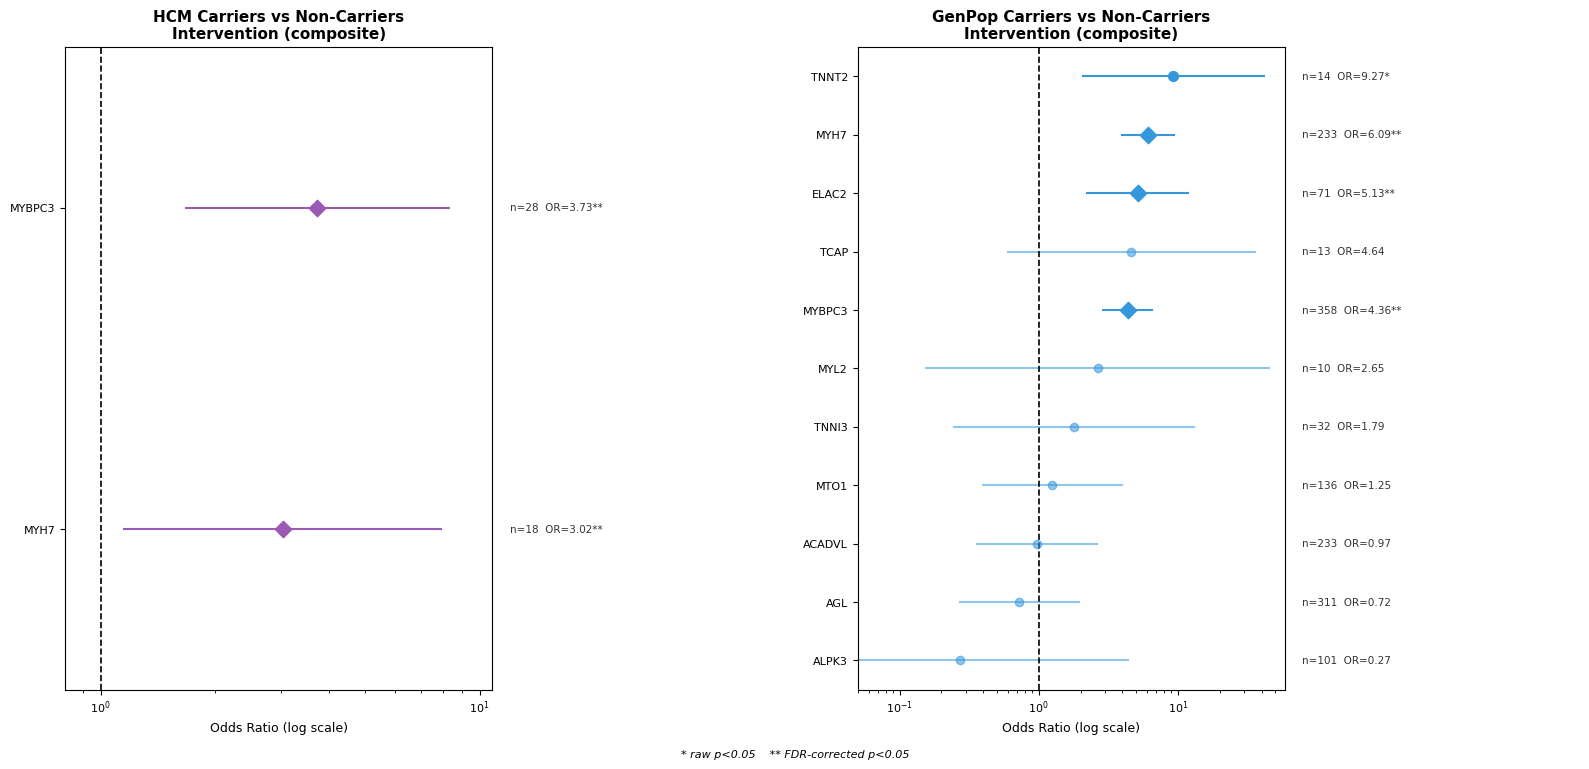

In [65]:
MIN_CARRIERS = 3
hcm_cohort_df = cohort[cohort["is_hcm_case"]]
genpop_cohort_df = cohort[~cohort["is_hcm_case"]]

for outcome_col in ["has_mace", "has_intervention"]:
    hcm_gene_or = gene_level_or(hcm_cohort_df, outcome_col)
    genpop_gene_or = gene_level_or(genpop_cohort_df, outcome_col)

    print(f"\n{EVENT_LABELS[outcome_col]} - HCM cohort, by gene:")
    print(hcm_gene_or.round(3).to_string(index=False) if len(hcm_gene_or) else "  (no gene meets MIN_CARRIERS)")

    print(f"\n{EVENT_LABELS[outcome_col]} - GenPop, by gene:")
    print(genpop_gene_or.round(3).to_string(index=False) if len(genpop_gene_or) else "  (no gene meets MIN_CARRIERS)")

    render_gene_forest(hcm_gene_or, genpop_gene_or, EVENT_LABELS[outcome_col],
                       f"{PLOT_DIR}/per_gene_enrichment_{outcome_col}.png")

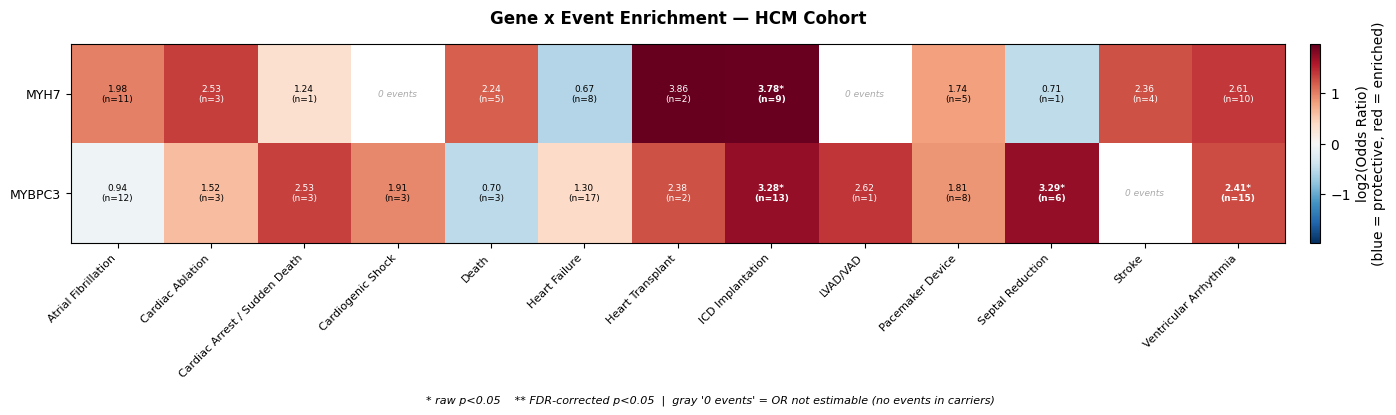

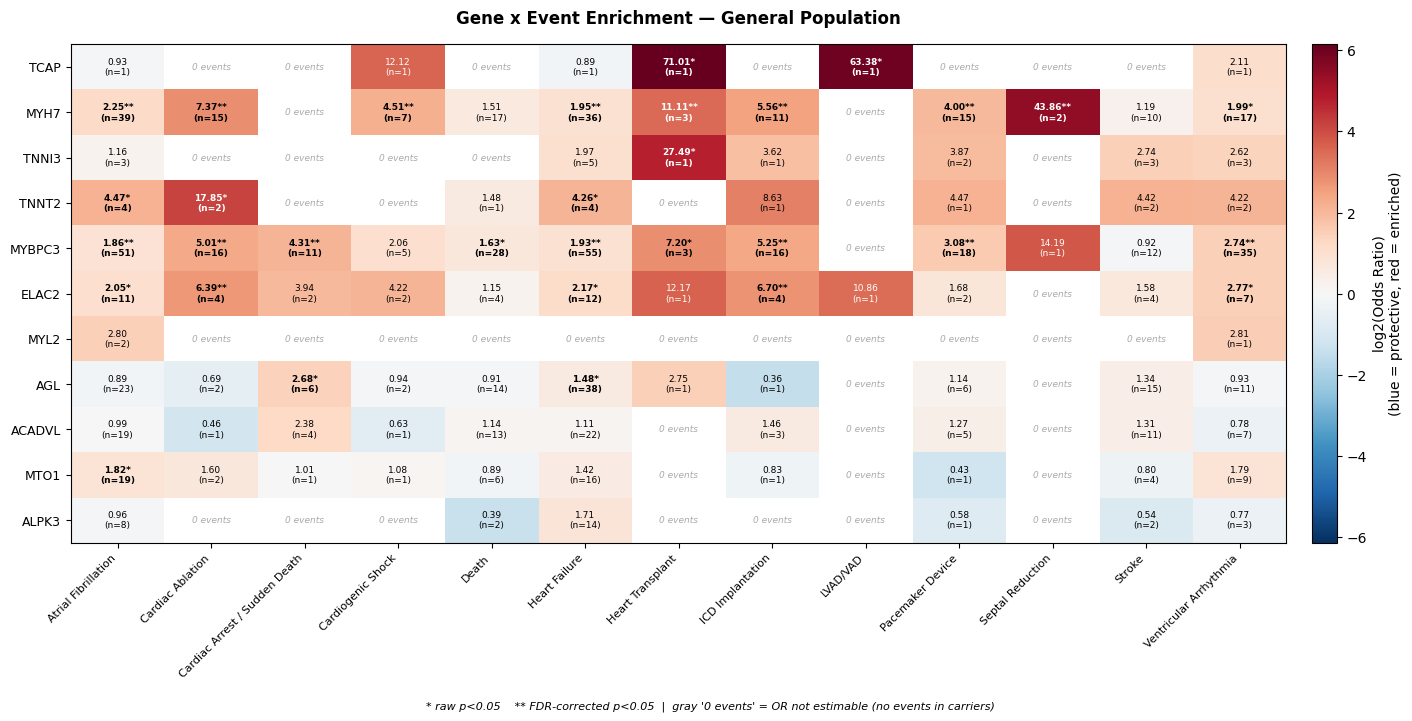


Top hits (FDR-significant), HCM cohort:
Empty DataFrame
Columns: [gene, event, n_carriers, or, p_fdr]
Index: []

Top hits (FDR-significant), GenPop:
  gene                         event  n_carriers        or    p_fdr
  MYH7              Septal Reduction         233 43.857408 0.011911
  MYH7              Heart Transplant         233 11.114702 0.026608
  MYH7              Cardiac Ablation         233  7.367897 0.000001
 ELAC2              ICD Implantation          71  6.698845 0.033152
 ELAC2              Cardiac Ablation          71  6.392842 0.036725
  MYH7              ICD Implantation         233  5.559740 0.000269
MYBPC3              ICD Implantation         358  5.249387 0.000015
MYBPC3              Cardiac Ablation         358  5.009596 0.000017
  MYH7             Cardiogenic Shock         233  4.505586 0.012647
MYBPC3 Cardiac Arrest / Sudden Death         358  4.311519 0.001209
  MYH7              Pacemaker Device         233  3.999330 0.000317
MYBPC3              Pacemaker Devi

In [68]:
# Run for both cohorts, across all individual events (not composites)
hcm_grid = gene_event_or_grid(hcm_cohort_df, EVENT_COLS)
genpop_grid = gene_event_or_grid(genpop_cohort_df, EVENT_COLS)

render_gene_event_heatmap(hcm_grid, "Gene x Event Enrichment — HCM Cohort", f"{PLOT_DIR}/gene_event_heatmap_hcm.png")
render_gene_event_heatmap(genpop_grid, "Gene x Event Enrichment — General Population", f"{PLOT_DIR}/gene_event_heatmap_genpop.png")

print("\nTop hits (FDR-significant), HCM cohort:")
print(hcm_grid[hcm_grid["sig_fdr"]].sort_values("or", ascending=False)[["gene", "event", "n_carriers", "or", "p_fdr"]].to_string(index=False) if len(hcm_grid) else "n/a")

print("\nTop hits (FDR-significant), GenPop:")
print(genpop_grid[genpop_grid["sig_fdr"]].sort_values("or", ascending=False)[["gene", "event", "n_carriers", "or", "p_fdr"]].to_string(index=False) if len(genpop_grid) else "n/a")

## Echo-Based Severity Analysis

**Purpose:** While the penetrance analysis (PRS quartile, Cox model) tests whether polygenic background affects *whether/when* a pathogenic-variant carrier develops HCM, this section asks a different question: among people with HCM (or carrying the variant), does polygenic/genetic status also affect *disease severity* — as reflected in echocardiographic structure and function?

**Data:** Echo measurements are pulled from the cardiology clinical measurements table (`nb_cs_cardiology_v2025_2_1`), long-format (`clinical_measurement_name` / `clinical_measurement_value`), joined to `hcm_master_cohort` and matched to each person's **closest available echo to their baseline date, unbounded** (no fixed time window — an earlier ±2-year window was tested and found to exclude a large fraction of real echo records, so unbounded closest-match was used instead; see coverage checks below for how far the matched echo typically sits from baseline).

### Composite Severity Index
To pool signal across multiple echo measures (each individually underpowered at this sample size) rather than testing them one at a time, a composite severity index was built:
- **Measures included:** interventricular septal thickness (`ivs_thick`), posterior wall thickness (`lvpw_thick`), LVOT peak gradient (`lvot_peak_gradient`), left atrial volume (`la_volume`), and average E/e′ ratio (`lv_average_e:e'_ratio`) — covering hypertrophy, outflow obstruction, atrial remodeling, and diastolic function.
- **Standardization:** each measure was z-scored against the GenPop Non-Carrier group (the closest available approximation to a genetically-normal reference population), so a value of 0 represents the population-typical/normal level and positive values represent greater severity.
- **Composite score:** the mean of all available z-scores per person, requiring at least 2 of 5 measures present; people with fewer than 2 available measures were excluded (echo field coverage varies considerably by measure and by cohort group — see coverage counts printed at each pull step).
- **Comparison:** HCM Carrier vs. HCM Non-Carrier vs. GenPop Carrier (GenPop Non-Carrier excluded from the comparison since it serves as the reference population by construction). Tested via Kruskal-Wallis (overall three-group difference) followed by pairwise Mann-Whitney tests with Bonferroni correction for the three pairwise comparisons.


**Key limitation across all echo analyses:** echo field coverage is incomplete and uneven across cohort groups (notably sparser in GenPop groups, where echo is not standard-of-care in the absence of a cardiac indication), and echo-to-baseline matching is unbounded, meaning some matched echoes may reflect timepoints well before or after actual baseline/diagnosis — this should be weighed against any severity findings from this section.

In [24]:
SEVERITY_MEASURES = ["ivs_thick", "lvpw_thick", "lvot_peak_gradient", "la_volume", "lv_average_e:e'_ratio"]
ECHO_DATASET = "clinical_specialty_collection"
ECHO_TABLE = "nb_cs_cardiology_v2025_2_1"

def sql_escape(s):
    return s.replace("'", "\\'")

measure_list_sql = ", ".join(f"'{sql_escape(m)}'" for m in SEVERITY_MEASURES)

severity_query = f"""
WITH ranked_echo AS (
  SELECT
    m.person_id,
    m.clinical_measurement_name,
    m.clinical_measurement_value,
    ABS(DATE_DIFF(m.clinical_measurement_date, b.baseline_date, DAY)) AS days_from_baseline,
    ROW_NUMBER() OVER (
      PARTITION BY m.person_id, m.clinical_measurement_name
      ORDER BY ABS(DATE_DIFF(m.clinical_measurement_date, b.baseline_date, DAY))
    ) AS rn
  FROM `{ECHO_DATASET}.{ECHO_TABLE}` m
  JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort` b
    ON m.person_id = b.person_id
  WHERE m.clinical_measurement_name IN ({measure_list_sql})
)
SELECT person_id, clinical_measurement_name, clinical_measurement_value
FROM ranked_echo
WHERE rn = 1
"""
severity_long_df = client.query(severity_query).to_dataframe()
print(f"Pulled {len(severity_long_df):,} measurement rows across {severity_long_df['person_id'].nunique():,} persons")

severity_wide_df = severity_long_df.pivot(index="person_id", columns="clinical_measurement_name",
                                            values="clinical_measurement_value").reset_index()
severity_wide_df = severity_wide_df.rename(columns={"lv_average_e:e'_ratio": "lv_avg_e_e_ratio"})

SEVERITY_MEASURES_CLEAN = ["ivs_thick", "lvpw_thick", "lvot_peak_gradient", "la_volume", "lv_avg_e_e_ratio"]

for col in SEVERITY_MEASURES_CLEAN:
    if col in severity_wide_df.columns:
        severity_wide_df[col] = pd.to_numeric(severity_wide_df[col], errors="coerce")

print("\nCoverage per measure:")
print(severity_wide_df[SEVERITY_MEASURES_CLEAN].notna().sum())

cohort = cohort.drop(columns=[c for c in SEVERITY_MEASURES_CLEAN if c in cohort.columns], errors="ignore")
cohort = cohort.merge(severity_wide_df, on="person_id", how="left")

Pulled 211,703 measurement rows across 62,529 persons

Coverage per measure:
clinical_measurement_name
ivs_thick             57132
lvpw_thick            61892
lvot_peak_gradient    40156
la_volume             25550
lv_avg_e_e_ratio      26973
dtype: int64


In [25]:
reference = cohort[cohort["cohort_group"] == "GenPop Non-Carrier"]

z_cols = []
for col in SEVERITY_MEASURES_CLEAN:
    ref_mean = reference[col].mean()
    ref_std = reference[col].std()
    z_col = f"{col}_z"
    cohort[z_col] = (cohort[col] - ref_mean) / ref_std
    z_cols.append(z_col)
    print(f"{col}: reference mean={ref_mean:.3f}, SD={ref_std:.3f}, n_ref={reference[col].notna().sum():,}")

cohort["n_measures_available"] = cohort[z_cols].notna().sum(axis=1)
cohort["severity_index"] = cohort[z_cols].mean(axis=1, skipna=True)
cohort.loc[cohort["n_measures_available"] < 2, "severity_index"] = np.nan

print(f"\nPersons with usable severity_index (≥2 measures): {cohort['severity_index'].notna().sum():,}")
print("\nBy cohort group:")
print(cohort.groupby("cohort_group")["severity_index"].apply(lambda x: f"{x.notna().sum():,} available"))

ivs_thick: reference mean=1.073, SD=0.338, n_ref=56,346
lvpw_thick: reference mean=1.017, SD=0.234, n_ref=61,062
lvot_peak_gradient: reference mean=4.425, SD=3.155, n_ref=39,587
la_volume: reference mean=51.227, SD=29.043, n_ref=25,145
lv_avg_e_e_ratio: reference mean=9.829, SD=7.171, n_ref=26,542

Persons with usable severity_index (≥2 measures): 57,093

By cohort group:
cohort_group
GenPop Carrier           478 available
GenPop Non-Carrier    56,306 available
HCM Carrier               45 available
HCM Non-Carrier          264 available
Name: severity_index, dtype: object


HCM Carrier: n=45, mean=1.325, median=1.179, SD=1.242
HCM Non-Carrier: n=264, mean=0.938, median=0.847, SD=1.177
GenPop Carrier: n=478, mean=0.234, median=0.170, SD=1.057

Kruskal-Wallis across 3 groups: H=106.054, p=0.0000


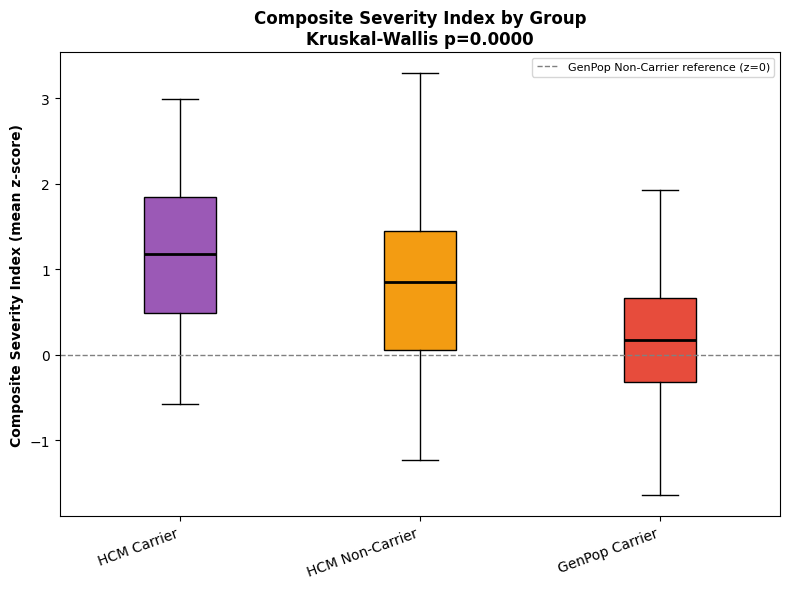


Pairwise comparisons (Bonferroni-adjusted for 3 tests):
  HCM Carrier vs HCM Non-Carrier: p=0.0373, Bonferroni p=0.1120
  HCM Carrier vs GenPop Carrier: p=0.0000, Bonferroni p=0.0000
  HCM Non-Carrier vs GenPop Carrier: p=0.0000, Bonferroni p=0.0000


In [27]:
groups_to_compare = ["HCM Carrier", "HCM Non-Carrier", "GenPop Carrier"]
group_colors = {"HCM Carrier": "#9b59b6", "HCM Non-Carrier": "#f39c12", "GenPop Carrier": "#e74c3c"}

group_data = {g: cohort.loc[(cohort["cohort_group"] == g) & cohort["severity_index"].notna(), "severity_index"]
              for g in groups_to_compare}

for g, data in group_data.items():
    print(f"{g}: n={len(data)}, mean={data.mean():.3f}, median={data.median():.3f}, SD={data.std():.3f}")

h_stat, p_kw = kruskal(*group_data.values())
print(f"\nKruskal-Wallis across 3 groups: H={h_stat:.3f}, p={p_kw:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(list(group_data.values()), tick_labels=groups_to_compare, patch_artist=True,
                 showfliers=False, medianprops=dict(color="black", linewidth=2))
for patch, g in zip(bp["boxes"], groups_to_compare):
    patch.set_facecolor(group_colors[g])
ax.axhline(0, color="gray", linestyle="--", linewidth=1, label="GenPop Non-Carrier reference (z=0)")
ax.set_ylabel("Composite Severity Index (mean z-score)", fontweight="bold")
ax.set_title(f"Composite Severity Index by Group\nKruskal-Wallis p={p_kw:.4f}", fontweight="bold")
ax.set_xticklabels(groups_to_compare, rotation=20, ha="right")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/composite_severity_index_by_group.png", dpi=300, bbox_inches="tight")
plt.show()

# Pairwise Mann-Whitney, with simple Bonferroni (3 comparisons)
from itertools import combinations
print("\nPairwise comparisons (Bonferroni-adjusted for 3 tests):")
for g1, g2 in combinations(groups_to_compare, 2):
    u, p = mannwhitneyu(group_data[g1], group_data[g2], alternative="two-sided")
    p_adj = min(p * 3, 1.0)
    print(f"  {g1} vs {g2}: p={p:.4f}, Bonferroni p={p_adj:.4f}")

HCM Carriers with severity_index and PRS quartile: 45
prs_quartile
Q1     4
Q2    11
Q3    12
Q4    18
Name: count, dtype: int64
Q1: n=4, mean=0.759, median=0.785
Q2: n=11, mean=0.852, median=0.538
Q3: n=12, mean=1.766, median=1.693
Q4: n=18, mean=1.446, median=1.388

Kruskal-Wallis across PRS quartiles: H=5.823, p=0.1206


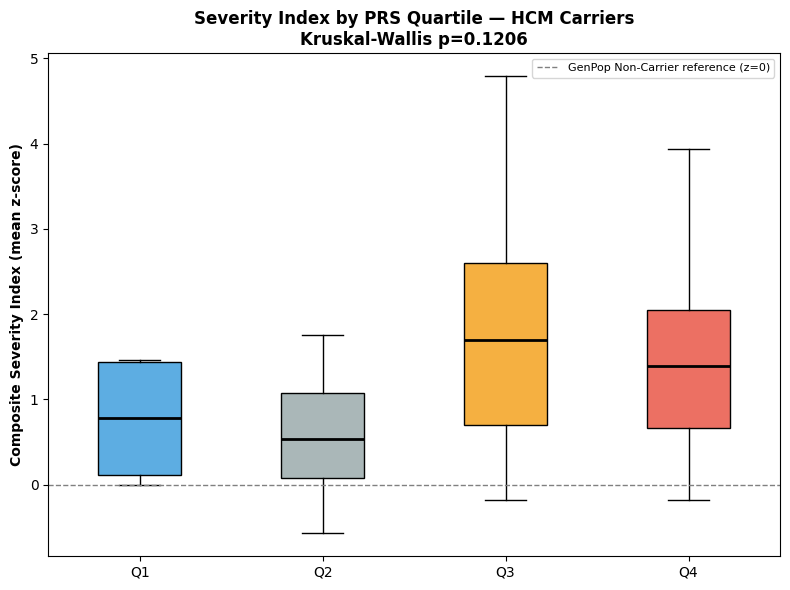


Linear regression, severity_index ~ PRS (continuous):
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.2451      0.203      6.122      0.000       0.835       1.655
prs_standardized     0.1662      0.174      0.957      0.344      -0.184       0.516


In [28]:
hcm_carrier_severity = cohort[(cohort["cohort_group"] == "HCM Carrier") & cohort["prs_quartile"].notna() 
                                & cohort["severity_index"].notna()]

print(f"HCM Carriers with severity_index and PRS quartile: {len(hcm_carrier_severity):,}")
print(hcm_carrier_severity["prs_quartile"].value_counts().reindex(["Q1", "Q2", "Q3", "Q4"]))

quartiles = ["Q1", "Q2", "Q3", "Q4"]
quartile_colors = {"Q1": "#5DADE2", "Q2": "#AAB7B8", "Q3": "#F5B041", "Q4": "#EC7063"}
q_data = {q: hcm_carrier_severity.loc[hcm_carrier_severity["prs_quartile"] == q, "severity_index"] for q in quartiles}

for q, data in q_data.items():
    print(f"{q}: n={len(data)}, mean={data.mean():.3f}, median={data.median():.3f}")

h_stat, p_kw = kruskal(*[d for d in q_data.values() if len(d) > 0])
print(f"\nKruskal-Wallis across PRS quartiles: H={h_stat:.3f}, p={p_kw:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot([q_data[q] for q in quartiles], tick_labels=quartiles, patch_artist=True,
                 showfliers=False, medianprops=dict(color="black", linewidth=2))
for patch, q in zip(bp["boxes"], quartiles):
    patch.set_facecolor(quartile_colors[q])
ax.axhline(0, color="gray", linestyle="--", linewidth=1, label="GenPop Non-Carrier reference (z=0)")
ax.set_ylabel("Composite Severity Index (mean z-score)", fontweight="bold")
ax.set_title(f"Severity Index by PRS Quartile — HCM Carriers\nKruskal-Wallis p={p_kw:.4f}", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/severity_index_by_prs_quartile_hcm_carriers.png", dpi=300, bbox_inches="tight")
plt.show()

# Continuous linear regression: more power than quartile binning at this n
model = smf.ols("severity_index ~ prs_standardized", data=hcm_carrier_severity).fit()
print("\nLinear regression, severity_index ~ PRS (continuous):")
print(model.summary().tables[1])

## 8. Summary

- **Carrier enrichment** : pathogenic HCM-panel variants are enriched
  in the HCM cohort relative to the full genotyped sample.
- **PRS distribution**: PRS differs by both disease status and carrier
  status, tested across GenPop/HCM x carrier/non-carrier.
- **CV event enrichment**: does carrier status predict event risk,
  overall and per gene, within each cohort?
- **Age of onset**: does carrier status predict earlier HCM diagnosis?
- **PRS-quartile penetrance & severity** — the primary hypothesis
  test: does PRS predict onset (GenPop carriers, HCM Cohort and/or severity
  (HCM carriers, event rates) in a dose-dependent way?

Report effect sizes, confidence intervals, and (multiple-testing-corrected)
p-values from §4-7 once populated. The primary hypothesis is supported to
the extent §7's GenPop-carrier forest plot and dose-response panel show a
significant, monotonic association between PRS quartile and `has_hcm`.